# Configuration and Setup

Establishing the computational environment and reproducibility framework:
- **Libraries**: Import NumPy, Pandas, TensorFlow, scikit-learn, matplotlib, seaborn, scipy
- **Reproducibility**: Set random seeds (Python, NumPy, TensorFlow) for deterministic results
- **Paths**: Configure directories for healthy and patient signal files
- **Parameters**: Define channel names (Fingergrip, Axial_Pressure, Tilt_X, Tilt_Y, Tilt_Z) excluding Microphone

These settings ensure consistent results across runs and proper data organization for analysis.


In [1]:
# =====================================
# CONFIGURATION AND SETUP
# =====================================

import os
import random
import numpy as np  
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from sklearn.utils import class_weight
import pickle
from sklearn.model_selection import train_test_split
from scipy.stats import entropy

# SET SEEDS FOR REPRODUCIBILITY
seed = 42

# Must be set before importing TensorFlow
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Set pandas display options
pd.set_option('display.max_columns', None)

# Base paths configuration
base_paths = {
    "healthy": r"C:\NewHandPD\Healthy Signals\Signal",
    "patient": r"C:\NewHandPD\Patient Signals\Signal"
}

category_labels = {
    "healthy": 0,
    "patient": 1
}

# Updated channel names (excluding Microphone)
channel_names = [
    "Fingergrip", "Axial_Pressure",
    "Tilt_X", "Tilt_Y", "Tilt_Z"
]

# Data Loading and Parsing

Processing raw signal files with metadata extraction:
- **File Parsing**: Custom function to read .txt files with XML-style metadata tags
- **Signal Extraction**: Load tabular signal data (1000 Hz sampling rate) and select 5 channels
- **Metadata Capture**: Extract Person_ID_Number, Age, Gender, Writing_Hand
- **Data Organization**: Separate files into sigMea (meander) and sigSp (spiral) categories

This pipeline converts unstructured text files into structured DataFrames for analysis.

In [2]:
# =====================================
# ENHANCED FILE PARSING FUNCTION
# =====================================

def parse_signal_file(file_path, label):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    meta_info = {}
    signal_start_idx = 0
    in_meta_section = False
    
    # Extract metadata
    for i, line in enumerate(lines):
        line = line.strip()
        
        if line == "#<meta>":
            in_meta_section = True
            continue
        elif line == "#</meta>":
            in_meta_section = False
            signal_start_idx = i + 1
            break
        
        if in_meta_section and line.startswith("#<") and ">" in line:
            try:
                # Find the opening tag
                tag_start = line.find("<") + 1
                tag_end = line.find(">")
                
                if tag_start > 0 and tag_end > tag_start:
                    key = line[tag_start:tag_end]
                    
                    # Extract value between > and </
                    value_start = tag_end + 1
                    closing_tag = f"</{key}>"
                    value_end = line.find(closing_tag)
                    
                    if value_end > value_start:
                        value = line[value_start:value_end]
                    else:
                        value = ""
                    
                    # Convert types
                    if value.isdigit():
                        value = int(value)
                    elif value.replace('.', '', 1).replace('-', '', 1).isdigit():
                        value = float(value)
                    elif value.lower() == 'true':
                        value = True
                    elif value.lower() == 'false':
                        value = False
                    elif value == '':
                        value = None
                    
                    meta_info[key] = value
            except Exception as e:
                print(f"Error parsing line '{line}': {e}")
                continue
    
    # Load signal data and drop first channel (Microphone)
    signal_lines = lines[signal_start_idx:]
    signal_array = np.loadtxt(signal_lines, delimiter="\t")
    
    if signal_array.ndim == 1:
        signal_array = signal_array[1:6].reshape(1, -1)
    else:
        signal_array = signal_array[:, 1:6]
    
    return signal_array, label, meta_info

In [3]:
# =====================================
# MAIN PROCESSING
# =====================================

all_records = []
sigMea_records = []
sigSp_records = []

metadata_fields = ['Person_ID_Number', 'Age', 'Gender', 'Writing_Hand']

for category, folder_path in base_paths.items():
    label = category_labels[category]
    print(f"Processing {category} files...")
    
    for file_name in tqdm(os.listdir(folder_path)):
        if not file_name.endswith(".txt"):
            continue
        
        file_path = os.path.join(folder_path, file_name)
        
        try:
            signal_data, label_val, meta_info = parse_signal_file(file_path, label)
            
            filtered_meta = {k: meta_info[k] for k in metadata_fields if k in meta_info}
            
            record = {
                "file_name": file_name,
                "label": label_val,
                "signal": signal_data,
                **filtered_meta
            }
            
            all_records.append(record)
            
            if file_name.startswith("sigMea"):
                sigMea_records.append(record)
            elif file_name.startswith("sigSp"):
                sigSp_records.append(record)
                
        except Exception as e:
            print(f"Error parsing {file_name}: {e}")

Processing healthy files...


100%|██████████| 421/421 [00:09<00:00, 46.61it/s]


Processing patient files...


100%|██████████| 373/373 [00:12<00:00, 30.07it/s]


In [4]:
# =====================================
# CREATE DATAFRAMES
# =====================================

df_all = pd.DataFrame(all_records)
df_sigMea = pd.DataFrame(sigMea_records)
df_sigSp = pd.DataFrame(sigSp_records)

print(f"\nSummary:")
print(f"Total files processed: {len(all_records)}")
print(f"Files starting with 'sigMea': {len(sigMea_records)}")
print(f"Files starting with 'sigSp': {len(sigSp_records)}")


Summary:
Total files processed: 792
Files starting with 'sigMea': 264
Files starting with 'sigSp': 264


# Exploratory Data Analysis (EDA)

Comprehensive analysis of dataset characteristics:

### Person-Level Analysis
- **Participant Distribution**: Count unique persons in healthy (n=X) and patient (n=Y) groups
- **Sample Distribution**: Visualize files per class with bar charts
- **Class Balance**: Assess dataset balance to identify potential bias

### Channel-Wise Statistics
- **Descriptive Statistics**: Mean, std, min, max, median for each sensor channel
- **Class Comparison**: Side-by-side comparison of healthy vs. patient signal characteristics
- **Amplitude Patterns**: Identify channels with discriminative power

### Signal Visualization
- **Time-Series Plots**: Visual comparison of sample signals from each class
- **Channel Analysis**: Display all 5 channels simultaneously for pattern recognition
- **Clinical Relevance**: Observe tremor, bradykinesia, and micrographia signatures

### Class Distribution
- **Overall Balance**: Proportion of healthy vs. patient samples
- **Task-Specific Distribution**: Class balance in meander vs. spiral tasks
- **Percentage Breakdown**: Quantitative assessment of dataset composition

### Basic Data Overview
- **DataFrame Structure**: Shape, columns, and data types
- **Summary Statistics**: Numerical summaries for all features
- **Data Quality**: Missing value detection and reporting

### Demographic Information
- **Age Analysis**: Distribution by class with histograms and boxplots
- **Gender Distribution**: Male/female representation in each class
- **Writing Hand**: Dominant hand preference analysis
- **Cross-Tabulation**: Demographic breakdowns by class with visualizations

These analyses reveal dataset characteristics, potential biases, and clinically relevant patterns.


PERSON-LEVEL ANALYSIS

--- Unique Persons ---
Total unique persons: 61
Healthy persons: 35
Patient persons: 26

--- Total Samples ---
Total samples: 792
Healthy samples: 420
Patient samples: 372


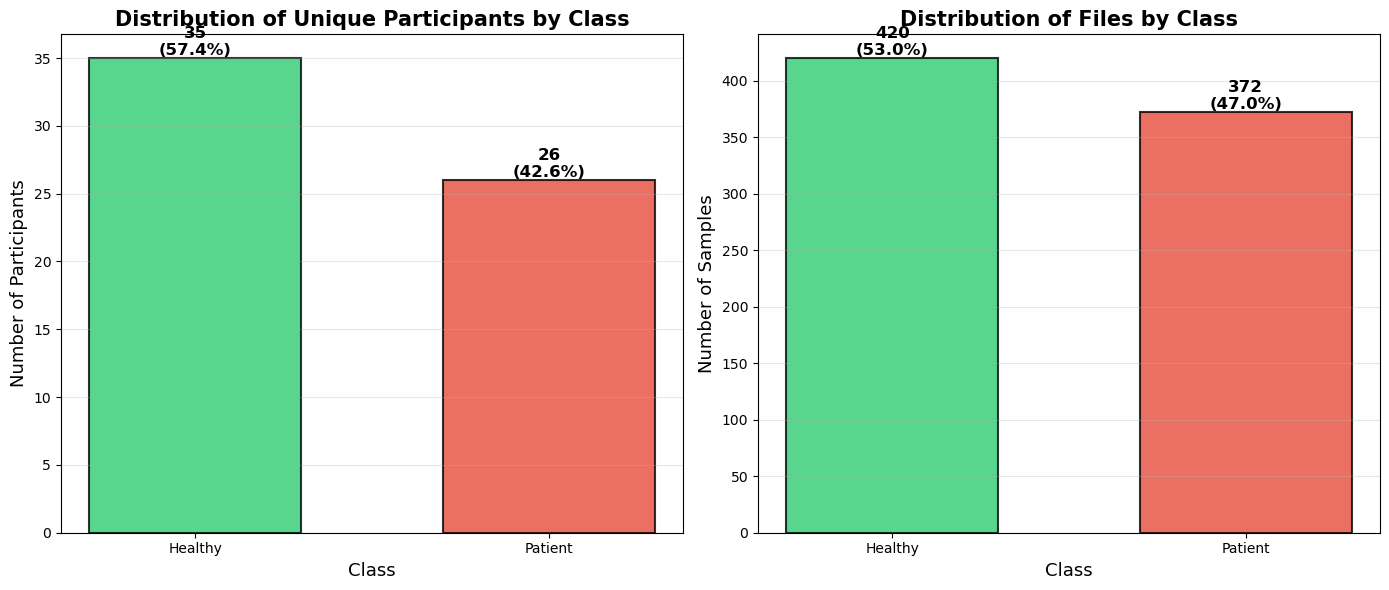

In [5]:
# =====================================
# EDA - PERSON-LEVEL ANALYSIS
# =====================================

print("="*70)
print("PERSON-LEVEL ANALYSIS")
print("="*70)

# Count unique persons
total_persons = df_all['Person_ID_Number'].nunique()
healthy_persons = df_all[df_all['label']==0]['Person_ID_Number'].nunique()
patient_persons = df_all[df_all['label']==1]['Person_ID_Number'].nunique()

print(f"\n--- Unique Persons ---")
print(f"Total unique persons: {total_persons}")
print(f"Healthy persons: {healthy_persons}")
print(f"Patient persons: {patient_persons}")

# Total samples
total_samples = len(df_all)
healthy_samples = len(df_all[df_all['label']==0])
patient_samples = len(df_all[df_all['label']==1])

print(f"\n--- Total Samples ---")
print(f"Total samples: {total_samples}")
print(f"Healthy samples: {healthy_samples}")
print(f"Patient samples: {patient_samples}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart: Unique persons by class
categories = ['Healthy', 'Patient']
person_counts = [healthy_persons, patient_persons]
bars = axes[0].bar(categories, person_counts, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6)
axes[0].set_ylabel('Number of Participants', fontsize=13)
axes[0].set_xlabel('Class', fontsize=13)
axes[0].set_title('Distribution of Unique Participants by Class', fontsize=15, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
# Add count labels on bars
for bar, count in zip(bars, person_counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{count}\n({count/total_persons*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

# Bar chart: Total samples by class
sample_counts = [healthy_samples, patient_samples]
bars = axes[1].bar(categories, sample_counts, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6)
axes[1].set_ylabel('Number of Samples', fontsize=13)
axes[1].set_xlabel('Class', fontsize=13)
axes[1].set_title('Distribution of Files by Class', fontsize=15, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
# Add count labels on bars
for bar, count in zip(bars, sample_counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{count}\n({count/total_samples*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

CHANNEL-WISE STATISTICS

--- Overall Channel Statistics ---
          Channel      Mean       Std       Min         Max    Median
0      Fingergrip  5.911716  1.062250 -0.019441  229.798881  5.943519
1  Axial_Pressure  5.954823  0.989917 -0.047373  225.162610  5.951642
2          Tilt_X  5.437357  0.782300  0.557550    8.334680  5.772360
3          Tilt_Y  4.273791  0.577419  0.021990    8.908720  4.190980
4          Tilt_Z  4.343840  0.619297  0.221040    8.821850  4.270160

--- Channel Statistics: Healthy ---
          Channel      Mean       Std       Min         Max    Median
0      Fingergrip  5.945100  1.213974 -0.019441  229.798881  5.957749
1  Axial_Pressure  5.957093  1.160947 -0.047373  225.162610  5.952259
2          Tilt_X  5.388960  0.821517  0.557550    8.289590  5.769060
3          Tilt_Y  4.429613  0.614251  0.059380    8.705280  4.380130
4          Tilt_Z  4.357288  0.664076  0.221040    8.821850  4.209680

--- Channel Statistics: Patient ---
          Channel      Mea

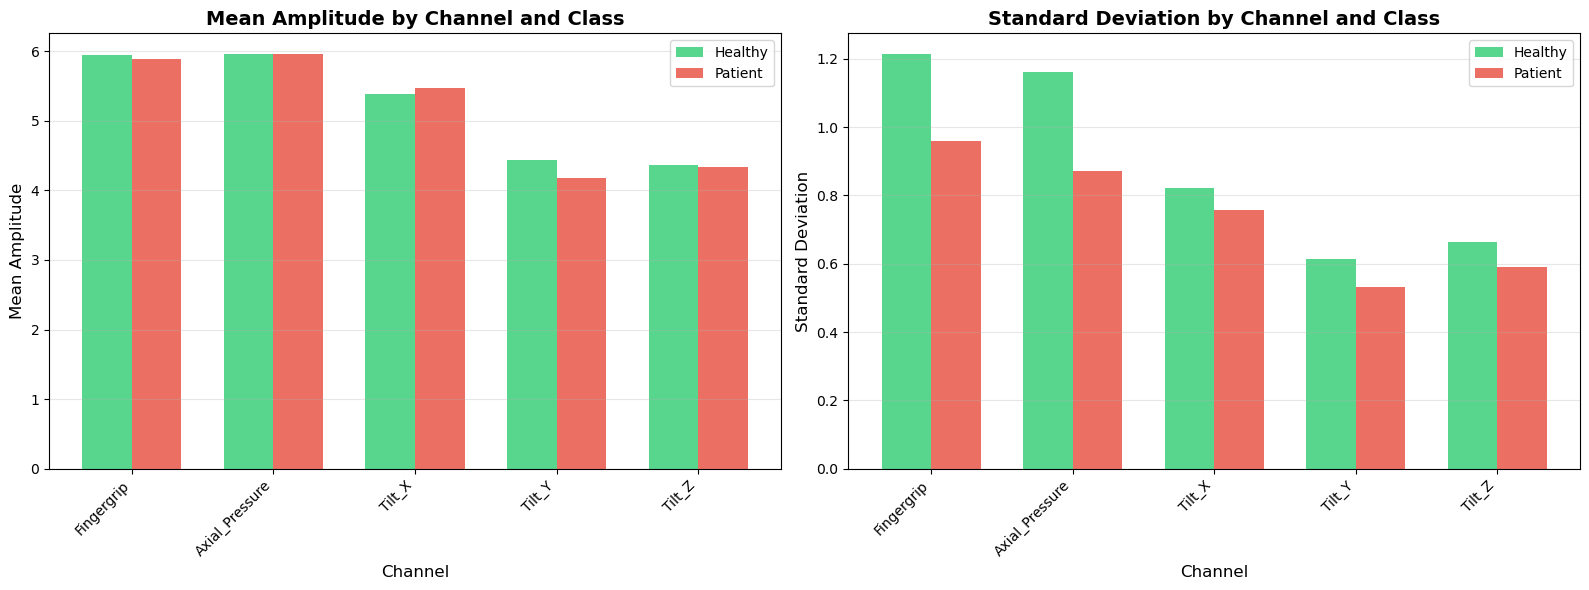

In [6]:
# =====================================
# EDA - CHANNEL-WISE STATISTICS
# =====================================

print("="*70)
print("CHANNEL-WISE STATISTICS")
print("="*70)

# Calculate statistics for each channel across all signals
def calculate_channel_stats(df, label_name):
    stats = []
    for i, channel in enumerate(channel_names):
        channel_data = np.concatenate([signal[:, i] for signal in df['signal'].values])
        stats.append({
            'Channel': channel,
            'Mean': channel_data.mean(),
            'Std': channel_data.std(),
            'Min': channel_data.min(),
            'Max': channel_data.max(),
            'Median': np.median(channel_data)
        })
    return pd.DataFrame(stats)

# Overall statistics
print("\n--- Overall Channel Statistics ---")
overall_stats = calculate_channel_stats(df_all, "Overall")
print(overall_stats)

# Statistics by class
print("\n--- Channel Statistics: Healthy ---")
healthy_stats = calculate_channel_stats(df_all[df_all['label']==0], "Healthy")
print(healthy_stats)

print("\n--- Channel Statistics: Patient ---")
patient_stats = calculate_channel_stats(df_all[df_all['label']==1], "Patient")
print(patient_stats)

# Visualize mean and std by channel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean comparison
x = np.arange(len(channel_names))
width = 0.35
axes[0].bar(x - width/2, healthy_stats['Mean'], width, label='Healthy', color='#2ecc71', alpha=0.8)
axes[0].bar(x + width/2, patient_stats['Mean'], width, label='Patient', color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Channel', fontsize=12)
axes[0].set_ylabel('Mean Amplitude', fontsize=12)
axes[0].set_title('Mean Amplitude by Channel and Class', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(channel_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Std comparison
axes[1].bar(x - width/2, healthy_stats['Std'], width, label='Healthy', color='#2ecc71', alpha=0.8)
axes[1].bar(x + width/2, patient_stats['Std'], width, label='Patient', color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Channel', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].set_title('Standard Deviation by Channel and Class', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(channel_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

SAMPLE SIGNAL VISUALIZATION

Healthy Sample: sigMea1-H13.txt
Patient Sample: sigSp3-P25.txt


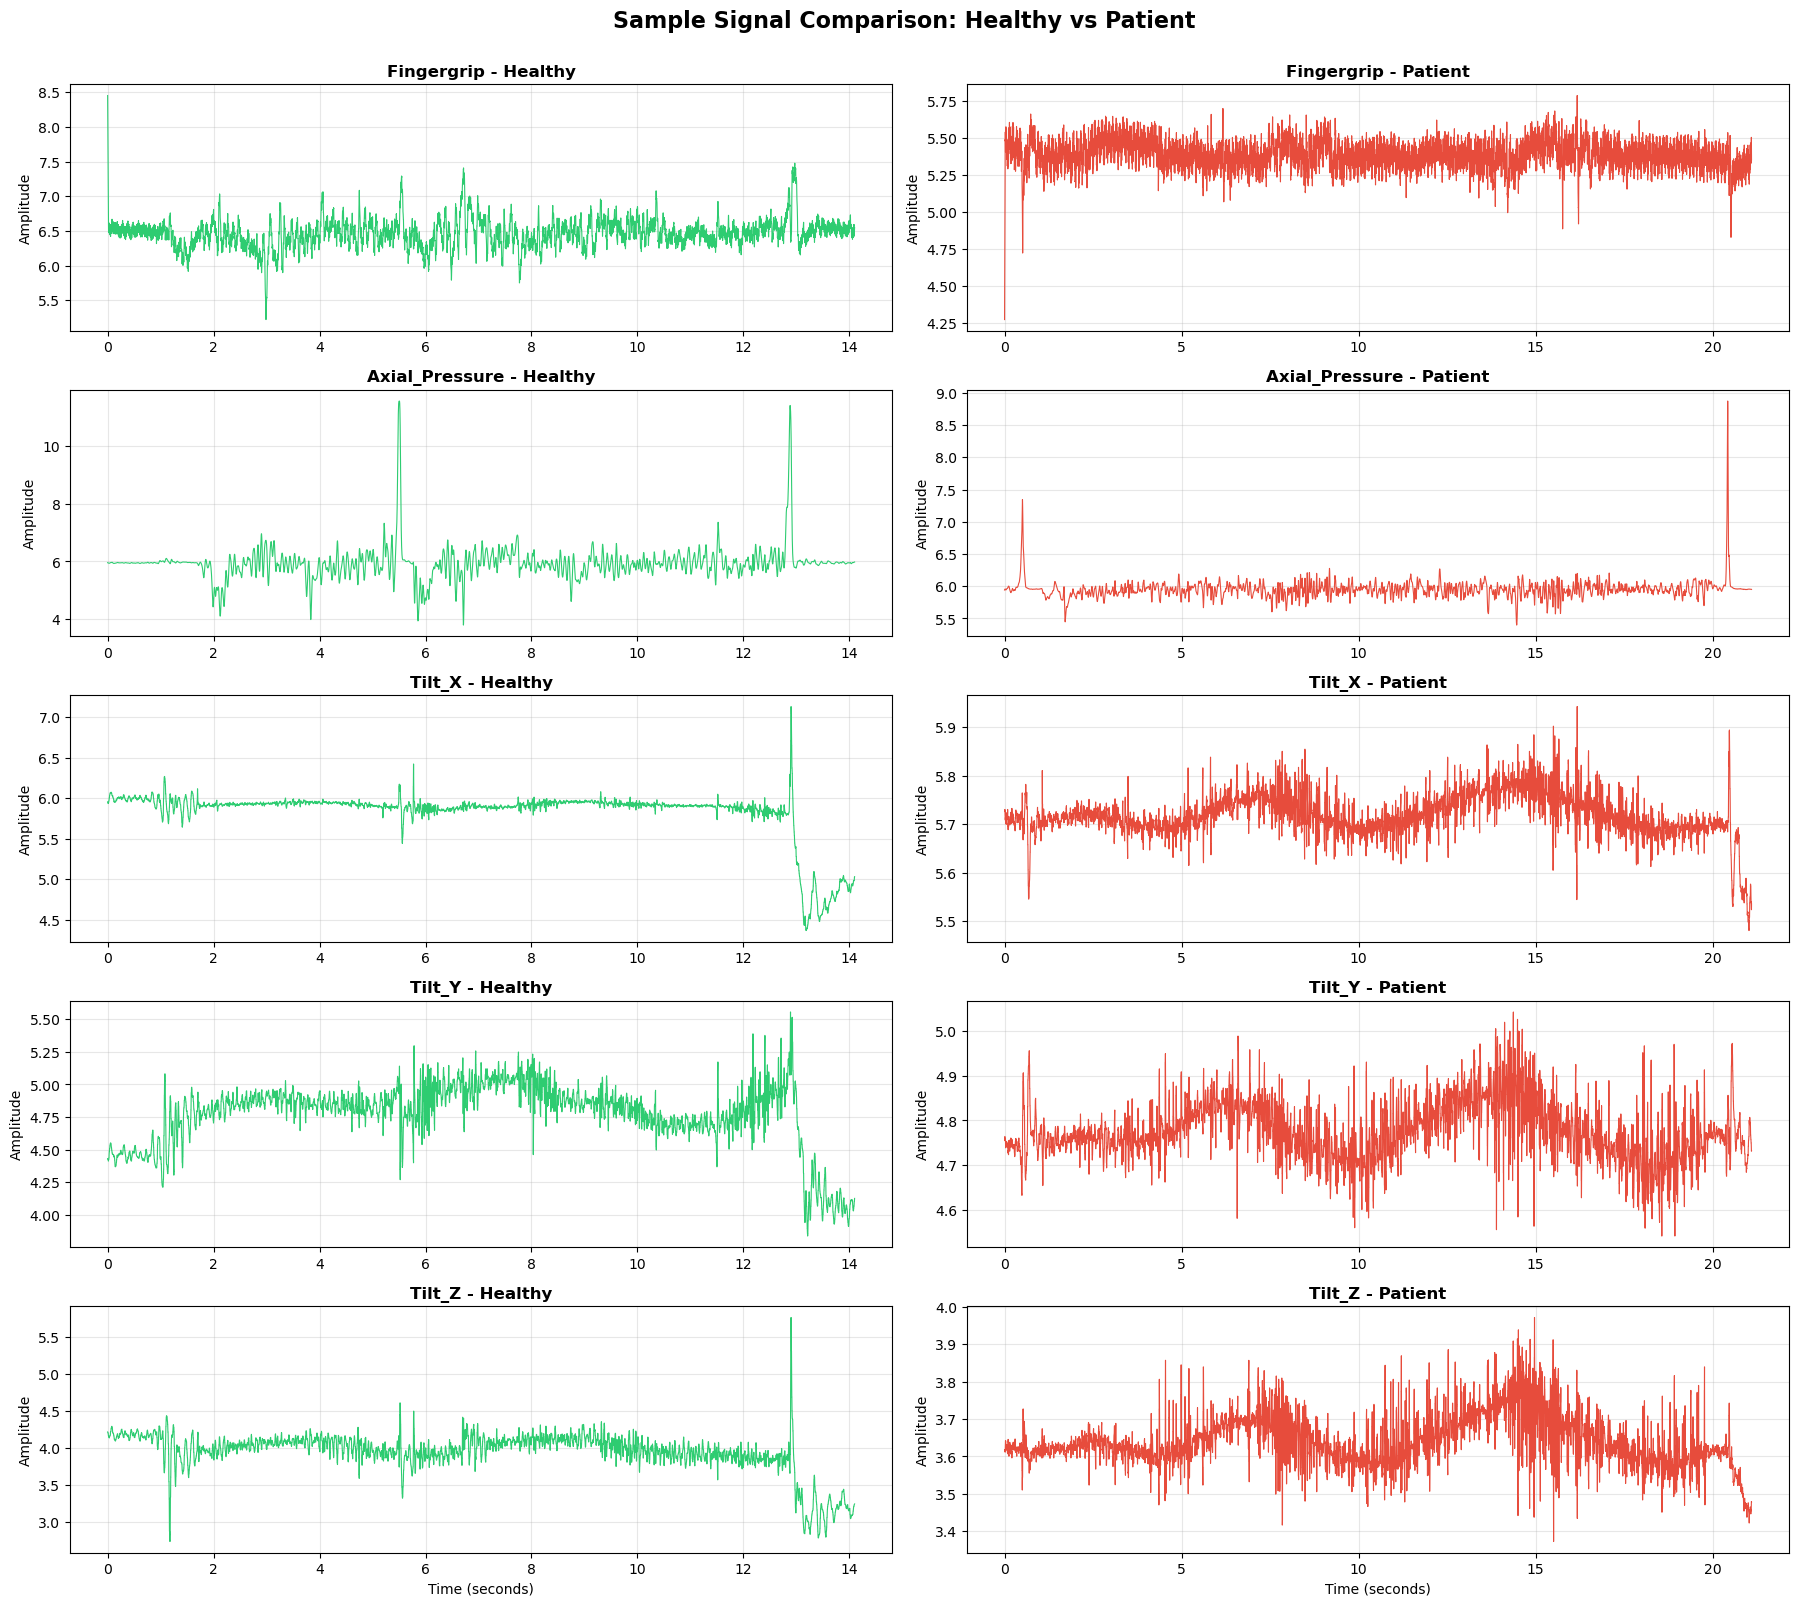

In [7]:
# =====================================
# EDA - SIGNAL VISUALIZATION (SAMPLE SIGNALS)
# =====================================

print("="*70)
print("SAMPLE SIGNAL VISUALIZATION")
print("="*70)

# Select random samples from each class
healthy_sample = df_all[df_all['label']==0].sample(1, random_state=seed).iloc[0]
patient_sample = df_all[df_all['label']==1].sample(1, random_state=seed).iloc[0]

print(f"\nHealthy Sample: {healthy_sample['file_name']}")
print(f"Patient Sample: {patient_sample['file_name']}")

# Plot all 5 channels for both samples
fig, axes = plt.subplots(5, 2, figsize=(18, 16))

for i, channel in enumerate(channel_names):
    # Healthy signal
    time_healthy = np.arange(len(healthy_sample['signal'])) / 1000  # Convert to seconds
    axes[i, 0].plot(time_healthy, healthy_sample['signal'][:, i], color='#2ecc71', linewidth=0.8)
    axes[i, 0].set_title(f'{channel} - Healthy', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Amplitude', fontsize=10)
    axes[i, 0].grid(alpha=0.3)
    
    if i == 4:  # Last subplot
        axes[i, 0].set_xlabel('Time (seconds)', fontsize=10)
    
    # Patient signal
    time_patient = np.arange(len(patient_sample['signal'])) / 1000  # Convert to seconds
    axes[i, 1].plot(time_patient, patient_sample['signal'][:, i], color='#e74c3c', linewidth=0.8)
    axes[i, 1].set_title(f'{channel} - Patient', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel('Amplitude', fontsize=10)
    axes[i, 1].grid(alpha=0.3)
    
    if i == 4:  # Last subplot
        axes[i, 1].set_xlabel('Time (seconds)', fontsize=10)

plt.suptitle('Sample Signal Comparison: Healthy vs Patient', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

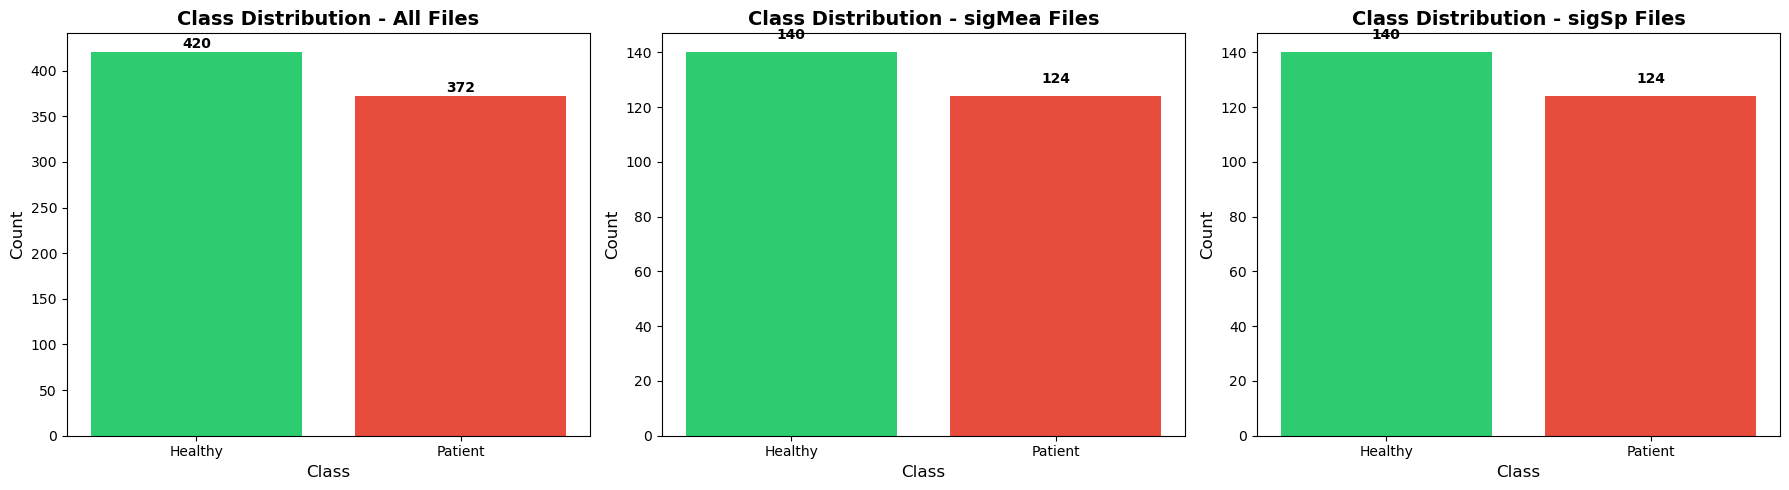


--- Class Distribution Percentages ---

df_all:
label
0    53.030303
1    46.969697
Name: proportion, dtype: float64

df_sigMea:
label
0    53.030303
1    46.969697
Name: proportion, dtype: float64

df_sigSp:
label
0    53.030303
1    46.969697
Name: proportion, dtype: float64


In [8]:
# =====================================
# EDA - CLASS DISTRIBUTION
# =====================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# df_all class distribution
class_counts_all = df_all['label'].value_counts()
axes[0].bar(['Healthy', 'Patient'], class_counts_all.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution - All Files', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
for i, v in enumerate(class_counts_all.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# df_sigMea class distribution
class_counts_sigMea = df_sigMea['label'].value_counts()
axes[1].bar(['Healthy', 'Patient'], class_counts_sigMea.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Class Distribution - sigMea Files', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
for i, v in enumerate(class_counts_sigMea.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# df_sigSp class distribution
class_counts_sigSp = df_sigSp['label'].value_counts()
axes[2].bar(['Healthy', 'Patient'], class_counts_sigSp.values, color=['#2ecc71', '#e74c3c'])
axes[2].set_title('Class Distribution - sigSp Files', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_xlabel('Class', fontsize=12)
for i, v in enumerate(class_counts_sigSp.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print percentages
print("\n--- Class Distribution Percentages ---")
print("\ndf_all:")
print(df_all['label'].value_counts(normalize=True) * 100)
print("\ndf_sigMea:")
print(df_sigMea['label'].value_counts(normalize=True) * 100)
print("\ndf_sigSp:")
print(df_sigSp['label'].value_counts(normalize=True) * 100)

In [9]:
# =====================================
# EXPLORATORY DATA ANALYSIS - BASIC OVERVIEW
# =====================================

print("="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# Display basic information about all dataframes
print("\n--- DataFrame Shapes ---")
print(f"df_all: {df_all.shape}")
print(f"df_sigMea: {df_sigMea.shape}")
print(f"df_sigSp: {df_sigSp.shape}")

# Display first few rows
print("\n--- First 5 Rows of df_all ---")
print(df_all.head())

# Display column information
print("\n--- DataFrame Info ---")
print(df_all.info())

# Display basic statistics
print("\n--- Basic Statistics ---")
print(df_all.describe())

# Check for missing values
print("\n--- Missing Values ---")
missing_counts = df_all.isnull().sum()
missing_percentages = (df_all.isnull().sum() / len(df_all)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage': missing_percentages
})
print(missing_df[missing_df['Missing Count'] > 0])

EXPLORATORY DATA ANALYSIS

--- DataFrame Shapes ---
df_all: (792, 7)
df_sigMea: (264, 7)
df_sigSp: (264, 7)

--- First 5 Rows of df_all ---
       file_name  label                                             signal  \
0   circA-H1.txt      0  [[7.42844620892122, 5.9721909807594, 5.92632, ...   
1  circA-H10.txt      0  [[5.8921503559182, 5.95510725758114, 5.89883, ...   
2  circA-H11.txt      0  [[6.11705476335663, 5.96571235460665, 5.44465,...   
3  circA-H12.txt      0  [[5.07455000073539, 5.95118141462297, 5.39626,...   
4  circA-H13.txt      0  [[6.68621376631096, 5.94761995388673, 5.59531,...   

      Person_ID_Number  Age  Gender  Writing_Hand  
0  201-110-281-657-521   58       1             1  
1  201-110-281-430-535   56       1             1  
2  201-012-071-239-550   56       2             1  
3  201-102-121-412-565   25       2             1  
4  201-012-080-708-597   30       2             1  

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 e

DEMOGRAPHIC ANALYSIS

--- Age Statistics ---
Mean Age: 50.3 years
Median Age: 55.0 years
Age Range: 14 - 79 years
Std Dev: 14.1 years

--- Age by Class ---
              mean  median        std  min  max
Healthy  43.366667    44.0  15.110692   14   79
Patient  58.032258    59.0   7.303142   38   78

--- Gender Distribution ---
Gender
1    421
2    371
Name: count, dtype: int64

Gender percentages:
Gender
1    53.156566
2    46.843434
Name: proportion, dtype: float64

--- Gender by Class ---
Gender           1          2
Healthy  48.809524  51.190476
Patient  58.064516  41.935484

--- Writing Hand Distribution ---
Writing_Hand
1    732
2     60
Name: count, dtype: int64

Writing Hand percentages:
Writing_Hand
1    92.424242
2     7.575758
Name: proportion, dtype: float64


C:\Users\Tristan\AppData\Local\Temp\ipykernel_22524\1352755394.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[0, 1].boxplot(age_data, labels=['Healthy', 'Patient'], patch_artist=True)


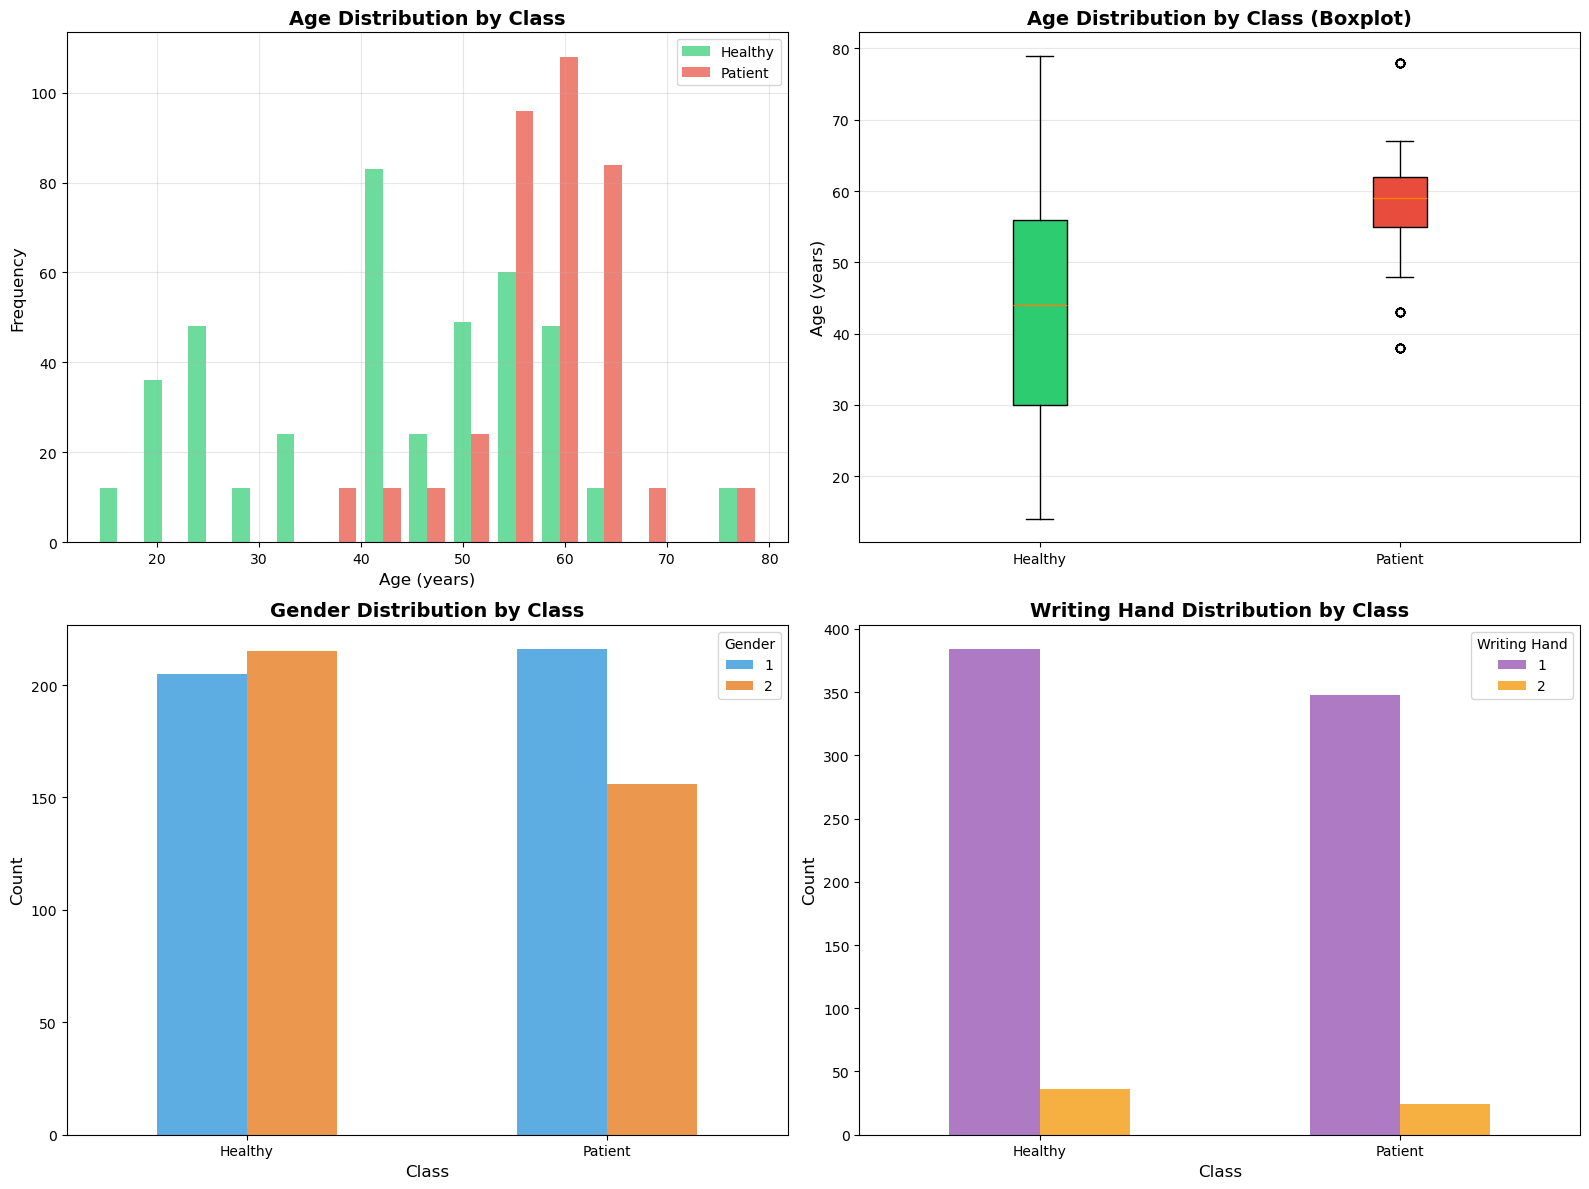

In [10]:
# =====================================
# EDA - DEMOGRAPHIC INFORMATION
# =====================================

print("="*70)
print("DEMOGRAPHIC ANALYSIS")
print("="*70)

# Age distribution
print("\n--- Age Statistics ---")
print(f"Mean Age: {df_all['Age'].mean():.1f} years")
print(f"Median Age: {df_all['Age'].median():.1f} years")
print(f"Age Range: {df_all['Age'].min():.0f} - {df_all['Age'].max():.0f} years")
print(f"Std Dev: {df_all['Age'].std():.1f} years")

# Age distribution by class
print("\n--- Age by Class ---")
age_by_class = df_all.groupby('label')['Age'].agg(['mean', 'median', 'std', 'min', 'max'])
age_by_class.index = ['Healthy', 'Patient']
print(age_by_class)

# Gender distribution
print("\n--- Gender Distribution ---")
gender_counts = df_all['Gender'].value_counts()
print(gender_counts)
print(f"\nGender percentages:")
print(df_all['Gender'].value_counts(normalize=True) * 100)

# Gender by class
print("\n--- Gender by Class ---")
gender_class = pd.crosstab(df_all['label'], df_all['Gender'], normalize='index') * 100
gender_class.index = ['Healthy', 'Patient']
print(gender_class)

# Writing Hand distribution
print("\n--- Writing Hand Distribution ---")
hand_counts = df_all['Writing_Hand'].value_counts()
print(hand_counts)
print(f"\nWriting Hand percentages:")
print(df_all['Writing_Hand'].value_counts(normalize=True) * 100)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age distribution histogram
axes[0, 0].hist([df_all[df_all['label']==0]['Age'].dropna(), 
                 df_all[df_all['label']==1]['Age'].dropna()],
                label=['Healthy', 'Patient'], 
                bins=15, 
                color=['#2ecc71', '#e74c3c'],
                alpha=0.7)
axes[0, 0].set_title('Age Distribution by Class', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Age boxplot by class
age_data = [df_all[df_all['label']==0]['Age'].dropna(), 
            df_all[df_all['label']==1]['Age'].dropna()]
box = axes[0, 1].boxplot(age_data, labels=['Healthy', 'Patient'], patch_artist=True)
for patch, color in zip(box['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
axes[0, 1].set_title('Age Distribution by Class (Boxplot)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Age (years)', fontsize=12)
axes[0, 1].grid(alpha=0.3, axis='y')

# Gender distribution
gender_class_counts = pd.crosstab(df_all['label'], df_all['Gender'])
gender_class_counts.index = ['Healthy', 'Patient']
gender_class_counts.plot(kind='bar', ax=axes[1, 0], color=['#3498db', '#e67e22'], alpha=0.8)
axes[1, 0].set_title('Gender Distribution by Class', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Class', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].legend(title='Gender')
axes[1, 0].set_xticklabels(['Healthy', 'Patient'], rotation=0)

# Writing Hand distribution
hand_class_counts = pd.crosstab(df_all['label'], df_all['Writing_Hand'])
hand_class_counts.index = ['Healthy', 'Patient']
hand_class_counts.plot(kind='bar', ax=axes[1, 1], color=['#9b59b6', '#f39c12'], alpha=0.8)
axes[1, 1].set_title('Writing Hand Distribution by Class', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Class', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].legend(title='Writing Hand')
axes[1, 1].set_xticklabels(['Healthy', 'Patient'], rotation=0)

plt.tight_layout()
plt.show()

# Data Cleaning

Quality assurance and data integrity procedures:
- **Missing Value Detection**: Identify files with incomplete signal/metadata
- **Null Removal**: Drop rows with missing critical fields (signal, label, file_name)
- **Impossible Value Filtering**: Remove signals with negative values (sensor constraint)
- **Cleaning Report**: Document removed samples and final dataset sizes

This ensures downstream analyses operate on valid, complete data.


In [11]:
# =====================================
# DATA CLEANING
# =====================================

# Initial shapes for reference
initial_all = df_all.shape[0]
initial_sigMea = df_sigMea.shape[0]
initial_sigSp = df_sigSp.shape[0]

print("Initial Row Counts:")
print(f"df_all: {initial_all}")
print(f"df_sigMea: {initial_sigMea}")
print(f"df_sigSp: {initial_sigSp}")

# Identify and remove missing values
def find_missing_rows(df, name):
    missing_rows = df[df[['signal', 'label', 'file_name']].isnull().any(axis=1)]
    if not missing_rows.empty:
        print(f"\nFiles with missing values in {name}:")
        print(missing_rows['file_name'].unique())
    return missing_rows

# Find missing rows before dropping
missing_rows_all = find_missing_rows(df_all, "df_all")
missing_rows_sigMea = find_missing_rows(df_sigMea, "df_sigMea")
missing_rows_sigSp = find_missing_rows(df_sigSp, "df_sigSp")

# Drop missing rows
df_all_clean = df_all.dropna(subset=['signal', 'label', 'file_name'])
df_sigMea_clean = df_sigMea.dropna(subset=['signal', 'label', 'file_name'])
df_sigSp_clean = df_sigSp.dropna(subset=['signal', 'label', 'file_name'])

# Count how many were removed
removed_missing_all = initial_all - df_all_clean.shape[0]
removed_missing_sigMea = initial_sigMea - df_sigMea_clean.shape[0]
removed_missing_sigSp = initial_sigSp - df_sigSp_clean.shape[0]

print("\nRemoved due to missing values:")
print(f"df_all: {removed_missing_all} rows removed")
print(f"df_sigMea: {removed_missing_sigMea} rows removed")
print(f"df_sigSp: {removed_missing_sigSp} rows removed")

# Identify and remove impossible values
def remove_impossible_values(df, name):
    mask = df['signal'].apply(lambda x: np.all(x >= 0))
    removed = df[~mask]
    if not removed.empty:
        print(f"\nFiles with impossible values in {name}:")
        print(removed['file_name'].unique())
    return df[mask], removed

df_all_clean, removed_impossible_all = remove_impossible_values(df_all_clean, "df_all")
df_sigMea_clean, removed_impossible_sigMea = remove_impossible_values(df_sigMea_clean, "df_sigMea")
df_sigSp_clean, removed_impossible_sigSp = remove_impossible_values(df_sigSp_clean, "df_sigSp")

print("\nRemoved due to impossible values:")
print(f"df_all: {removed_impossible_all.shape[0]} rows removed")
print(f"df_sigMea: {removed_impossible_sigMea.shape[0]} rows removed")
print(f"df_sigSp: {removed_impossible_sigSp.shape[0]} rows removed")

# Final Summary
print("\nData cleaning complete:")
print(f"df_all_clean shape: {df_all_clean.shape}")
print(f"df_sigMea_clean shape: {df_sigMea_clean.shape}")
print(f"df_sigSp_clean shape: {df_sigSp_clean.shape}")

Initial Row Counts:
df_all: 792
df_sigMea: 264
df_sigSp: 264

Removed due to missing values:
df_all: 0 rows removed
df_sigMea: 0 rows removed
df_sigSp: 0 rows removed

Files with impossible values in df_all:
['sigMea2-H26.txt' 'sigMea4-H26.txt' 'sigSp1-H26.txt']

Files with impossible values in df_sigMea:
['sigMea2-H26.txt' 'sigMea4-H26.txt']

Files with impossible values in df_sigSp:
['sigSp1-H26.txt']

Removed due to impossible values:
df_all: 3 rows removed
df_sigMea: 2 rows removed
df_sigSp: 1 rows removed

Data cleaning complete:
df_all_clean shape: (789, 7)
df_sigMea_clean shape: (262, 7)
df_sigSp_clean shape: (263, 7)


# Data Splitting

Stratified person-level train-test separation:
- **Combination**: Merge sigMea and sigSp cleaned datasets
- **Person-Level Split**: 85% train / 15% test stratified by class (prevents data leakage)
- **Stratification Verification**: Confirm class proportions preserved in both sets
- **Leakage Check**: Verify no person appears in both train and test sets

This splitting strategy ensures independent evaluation and realistic generalization assessment.

In [12]:
# =====================================
# COMBINE AND SPLIT DATA (STRATIFIED)
# =====================================

# Combine DataFrames
df_combined = pd.concat([df_sigMea_clean, df_sigSp_clean], ignore_index=True)
print(f"Combined DataFrame shape: {df_combined.shape}")

# Create a helper DataFrame with one entry per person and their label
person_labels = df_combined.drop_duplicates(subset='Person_ID_Number')[['Person_ID_Number', 'label']]

# Use train_test_split to get stratified lists of Person IDs
train_ids, test_ids = train_test_split(
    person_labels['Person_ID_Number'],        
    test_size=0.15,                            
    random_state=seed,                         
    stratify=person_labels['label']           
)

# Create the final training and testing DataFrames using the stratified IDs
df_train = df_combined[df_combined['Person_ID_Number'].isin(train_ids)]
df_test = df_combined[df_combined['Person_ID_Number'].isin(test_ids)]

print("\nData Split Summary:")
print(f"Total number of unique persons: {len(person_labels)}")
print(f"Training set: {len(train_ids)} persons, {len(df_train)} samples")
print(f"Test set: {len(test_ids)} persons, {len(df_test)} samples")

# Verify no data leakage
train_ids_set = set(df_train['Person_ID_Number'].unique())
test_ids_set = set(df_test['Person_ID_Number'].unique())

print("\nChecking for data leakage:")
print(f"Overlap between train and test: {len(train_ids_set & test_ids_set)}")

# Verify the class distribution
print("\nVerifying Stratification:")
print("Overall class distribution:")
print(df_combined['label'].value_counts(normalize=True))
print("\nTraining set class distribution:")
print(df_train['label'].value_counts(normalize=True))
print("\nTest set class distribution:")
print(df_test['label'].value_counts(normalize=True))

Combined DataFrame shape: (525, 7)

Data Split Summary:
Total number of unique persons: 61
Training set: 51 persons, 445 samples
Test set: 10 persons, 80 samples

Checking for data leakage:
Overlap between train and test: 0

Verifying Stratification:
Overall class distribution:
label
0    0.527619
1    0.472381
Name: proportion, dtype: float64

Training set class distribution:
label
0    0.514607
1    0.485393
Name: proportion, dtype: float64

Test set class distribution:
label
0    0.6
1    0.4
Name: proportion, dtype: float64


# Data Augmentation

Adaptive signal augmentation for training set enhancement:

### Augmentation Techniques
- **Jitter**: Add Gaussian noise (σ=0.005-0.02) to simulate sensor variability
- **Time Warping**: Apply temporal distortion (0.8-1.2x) using cubic spline interpolation
- **Adaptive Strategy**: Adjust augmentation intensity based on signal duration

### Implementation
- **Duration Analysis**: Calculate mean, median, std of signal lengths
- **Thresholding**: Classify signals as short, normal, or long
- **Augmentation Application**: Generate 2-3 augmented versions per signal with reproducible seeding

### Quality Assessment
- **Duration Normalization**: Histogram comparison before/after augmentation
- **Class Balance**: Verify proportional augmentation across classes
- **Sample Comparison**: Overlay original vs. augmented signals for visual validation

Augmentation increases dataset size 3x while preserving signal characteristics and class balance.

Signal duration statistics:
Mean duration: 16754.38
Median duration: 13800.00
Standard deviation: 9428.09
Target duration: 13800
Short threshold: 9085.95
Long threshold: 18514.05

Applying data augmentation to training set...


100%|██████████| 445/445 [00:07<00:00, 60.87it/s]



Augmentation Statistics:
Final training set size: 1244 signals
Original signals: 445
Augmented signals: 799

Duration Statistics:
Original mean duration: 16754.38
Original std duration: 9428.09
Final mean duration: 13852.70
Final std duration: 6466.37


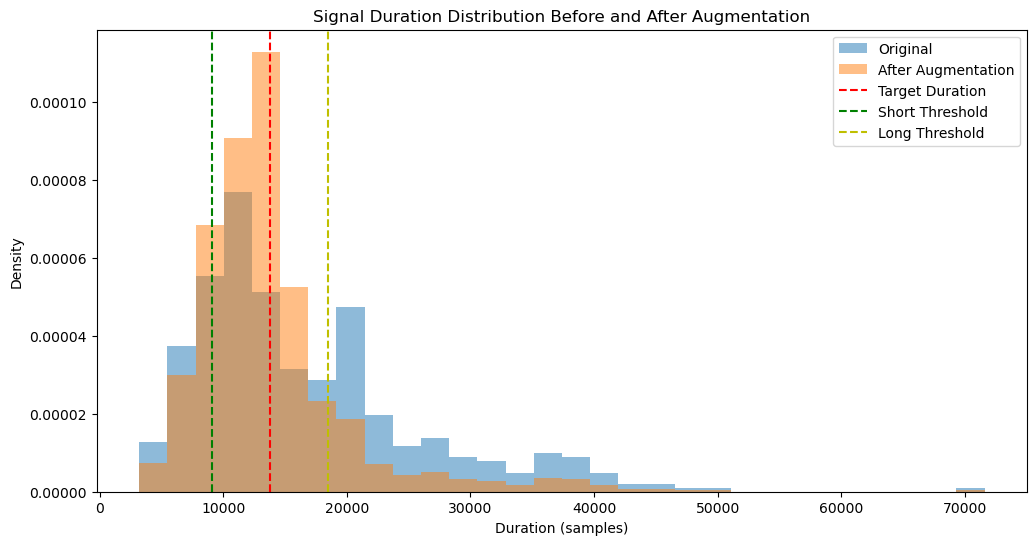

In [13]:
# =====================================
# DATA AUGMENTATION
# =====================================

def apply_jitter(signal, rng, noise_level=0.01):
    """Add Gaussian noise with reproducible seeding"""
    noise = rng.normal(0, noise_level, signal.shape)
    return signal + noise


def apply_time_warp(signal, rng, target_length=None, warp_factor_range=(0.8, 1.2)):
    """Apply time warping with reproducible seeding"""
    orig_len = len(signal)

    if target_length is not None:
        warp_factor = target_length / orig_len
        warp_factor *= rng.uniform(0.95, 1.05)  # small random variation
    else:
        warp_factor = rng.uniform(*warp_factor_range)

    new_len = int(orig_len * warp_factor)

    old_time = np.arange(orig_len)
    new_time = np.linspace(0, orig_len - 1, new_len)

    warped_signal = np.zeros((new_len, signal.shape[1]))
    for i in range(signal.shape[1]):
        interpolator = interp.CubicSpline(old_time, signal[:, i])
        warped_signal[:, i] = interpolator(new_time)

    if target_length is None:
        final_time = np.linspace(0, new_len - 1, orig_len)
        final_signal = np.zeros((orig_len, signal.shape[1]))
        for i in range(signal.shape[1]):
            interpolator = interp.CubicSpline(new_time, warped_signal[:, i])
            final_signal[:, i] = interpolator(final_time)
        return final_signal

    return warped_signal

# Calculate duration statistics for adaptive augmentation
signal_durations = df_train['signal'].apply(len)
mean_duration = signal_durations.mean()
median_duration = signal_durations.median()
std_duration = signal_durations.std()
target_duration = int(median_duration)  # Use median as target to reduce impact of outliers

# Group signals by length categories
short_threshold = median_duration - 0.5 * std_duration
long_threshold = median_duration + 0.5 * std_duration

print(f"Signal duration statistics:")
print(f"Mean duration: {mean_duration:.2f}")
print(f"Median duration: {median_duration:.2f}")
print(f"Standard deviation: {std_duration:.2f}")
print(f"Target duration: {target_duration}")
print(f"Short threshold: {short_threshold:.2f}")
print(f"Long threshold: {long_threshold:.2f}")

# Create seeded RNG once
rng = np.random.RandomState(seed)

augmented_records = []
original_records = []

print("\nApplying data augmentation to training set...")

# Keep originals
for record in df_train.to_dict('records'):
    record['augmented'] = False
    original_records.append(record)

# Augment
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    original_signal = row['signal']
    signal_length = len(original_signal)

    if signal_length < short_threshold:
        n_augmentations = 2
        target_lengths = [int(signal_length * rng.uniform(1.1, 1.3)) for _ in range(n_augmentations)]
    elif signal_length > long_threshold:
        n_augmentations = min(3, int(signal_length / median_duration))
        target_lengths = [int(target_duration * rng.uniform(0.9, 1.1)) for _ in range(n_augmentations)]
    else:
        n_augmentations = 2
        target_lengths = [int(signal_length * rng.uniform(0.9, 1.1)) for _ in range(n_augmentations)]

    for target_length in target_lengths:
        new_record = row.copy()
        augmented_signal = original_signal.copy()

        noise_level = rng.uniform(0.005, 0.02)
        augmented_signal = apply_jitter(augmented_signal, rng, noise_level)

        augmented_signal = apply_time_warp(augmented_signal, rng, target_length=target_length)

        new_record['signal'] = augmented_signal
        new_record['augmented'] = True
        new_record['original_duration'] = signal_length
        new_record['target_duration'] = target_length
        augmented_records.append(new_record)

df_train = pd.DataFrame(original_records + augmented_records)

# Print statistics about the augmentation
print("\nAugmentation Statistics:")
print(f"Final training set size: {len(df_train)} signals")
print(f"Original signals: {len(df_train[df_train['augmented'] == False])}")
print(f"Augmented signals: {len(df_train[df_train['augmented'] == True])}")

# Calculate and print duration statistics
final_durations = df_train['signal'].apply(len)
print("\nDuration Statistics:")
print(f"Original mean duration: {mean_duration:.2f}")
print(f"Original std duration: {std_duration:.2f}")
print(f"Final mean duration: {final_durations.mean():.2f}")
print(f"Final std duration: {final_durations.std():.2f}")

# Plot duration distribution before and after augmentation
plt.figure(figsize=(12, 6))
plt.hist(signal_durations, bins=30, alpha=0.5, label='Original', density=True)
plt.hist(final_durations, bins=30, alpha=0.5, label='After Augmentation', density=True)
plt.axvline(median_duration, color='r', linestyle='--', label='Target Duration')
plt.axvline(short_threshold, color='g', linestyle='--', label='Short Threshold')
plt.axvline(long_threshold, color='y', linestyle='--', label='Long Threshold')
plt.title('Signal Duration Distribution Before and After Augmentation')
plt.xlabel('Duration (samples)')
plt.ylabel('Density')
plt.legend()
plt.show()


--- Augmentation Summary ---
augmented  False  True 
Healthy      229    448
Patient      216    351


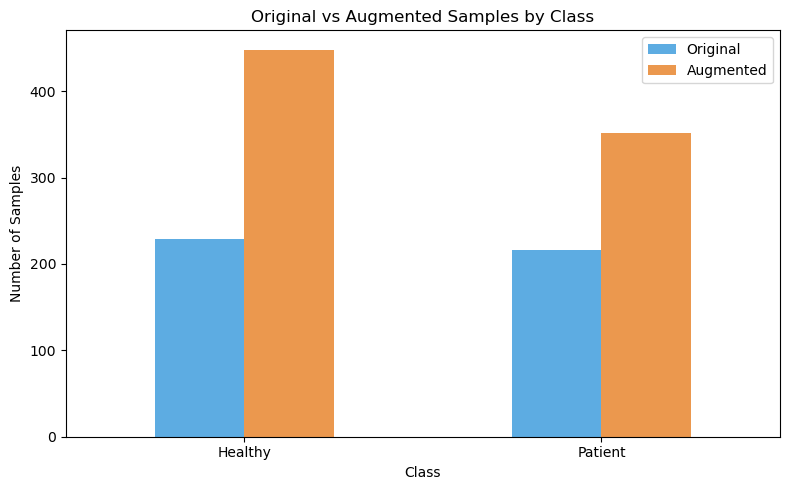

In [14]:
# =====================================
# DATA AUGMENTATION VISUALIZATIONS
# =====================================

print("\n--- Augmentation Summary ---")
aug_by_class = df_train.groupby(['label', 'augmented']).size().unstack(fill_value=0)
aug_by_class.index = ['Healthy', 'Patient']
print(aug_by_class)

# Simple bar chart showing augmentation effect
aug_by_class.plot(kind='bar', color=['#3498db', '#e67e22'], alpha=0.8, figsize=(8, 5))
plt.title('Original vs Augmented Samples by Class')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.legend(['Original', 'Augmented'])
plt.tight_layout()
plt.show()


--- Sample Signal Comparison: Original vs Augmented ---
File: sigSp3-H17.txt
Original length: 10900 samples (10.90s)
Augmented length: 10197 samples (10.20s)


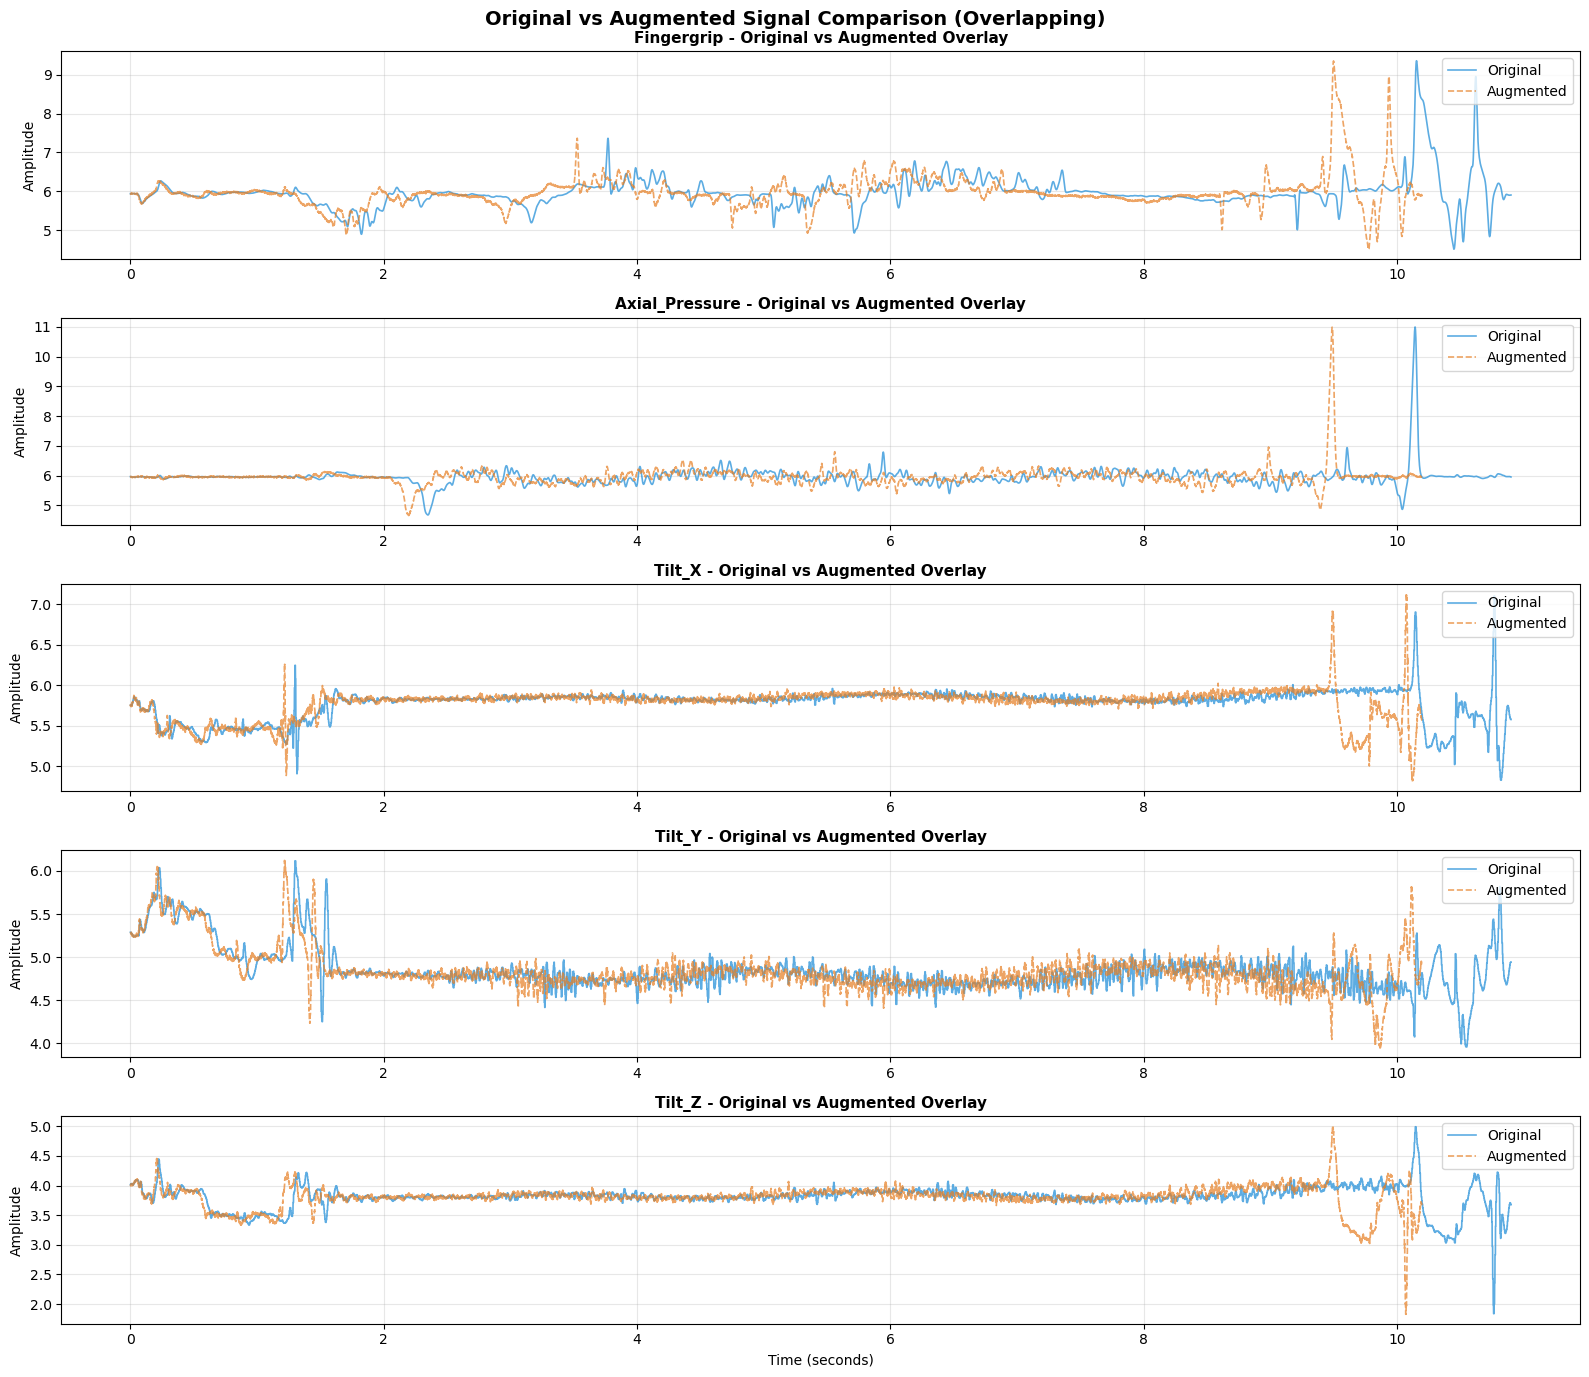


--- Statistical Comparison ---
          Channel  Original Mean  Augmented Mean  Original Std  Augmented Std
0      Fingergrip       5.973143        5.973137      0.419605       0.419688
1  Axial_Pressure       5.954246        5.954330      0.335892       0.336054
2          Tilt_X       5.780751        5.780721      0.183729       0.184046
3          Tilt_Y       4.846504        4.846574      0.253378       0.253573
4          Tilt_Z       3.807527        3.807485      0.194614       0.194850


In [15]:
# =====================================
# SAMPLE SIGNAL COMPARISON: ORIGINAL VS AUGMENTED
# =====================================

print("\n--- Sample Signal Comparison: Original vs Augmented ---")

# Select one original signal and find its augmented versions
sample_file = df_train[df_train['augmented']==False].sample(1, random_state=seed).iloc[0]
original_signal = sample_file['signal']
file_name = sample_file['file_name']

# Get augmented versions of the same file
augmented_versions = df_train[(df_train['file_name']==file_name) & (df_train['augmented']==True)]

if not augmented_versions.empty:
    augmented_signal = augmented_versions.sample(1, random_state=seed).iloc[0]['signal']
    
    print(f"File: {file_name}")
    print(f"Original length: {len(original_signal)} samples ({len(original_signal)/1000:.2f}s)")
    print(f"Augmented length: {len(augmented_signal)} samples ({len(augmented_signal)/1000:.2f}s)")
    
    # Plot all 5 channels with overlapping signals
    fig, axes = plt.subplots(5, 1, figsize=(16, 14))
    
    for i, channel in enumerate(channel_names):
        # Plot both signals overlapping
        time_orig = np.arange(len(original_signal)) / 1000
        time_aug = np.arange(len(augmented_signal)) / 1000
        
        axes[i].plot(time_orig, original_signal[:, i], color='#3498db', linewidth=1.2, 
                     label='Original', alpha=0.8)
        axes[i].plot(time_aug, augmented_signal[:, i], color='#e67e22', linewidth=1.2, 
                     label='Augmented', alpha=0.7, linestyle='--')
        
        axes[i].set_title(f'{channel} - Original vs Augmented Overlay', fontweight='bold', fontsize=11)
        axes[i].set_ylabel('Amplitude')
        axes[i].legend(loc='upper right')
        axes[i].grid(alpha=0.3)
        
        if i == 4:
            axes[i].set_xlabel('Time (seconds)')
    
    plt.suptitle('Original vs Augmented Signal Comparison (Overlapping)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Statistical comparison
    print("\n--- Statistical Comparison ---")
    stats_comparison = []
    for i, channel in enumerate(channel_names):
        stats_comparison.append({
            'Channel': channel,
            'Original Mean': original_signal[:, i].mean(),
            'Augmented Mean': augmented_signal[:, i].mean(),
            'Original Std': original_signal[:, i].std(),
            'Augmented Std': augmented_signal[:, i].std()
        })
    
    stats_df = pd.DataFrame(stats_comparison)
    print(stats_df)
else:
    print("No augmented versions found for the selected file.")


--- Class Balance Analysis ---

Overall Class Distribution:
  Healthy (0): 677 samples (54.42%)
  Patient (1): 567 samples (45.58%)

Original Samples:
  Healthy: 229, Patient: 216

Augmented Samples:
  Healthy: 448, Patient: 351


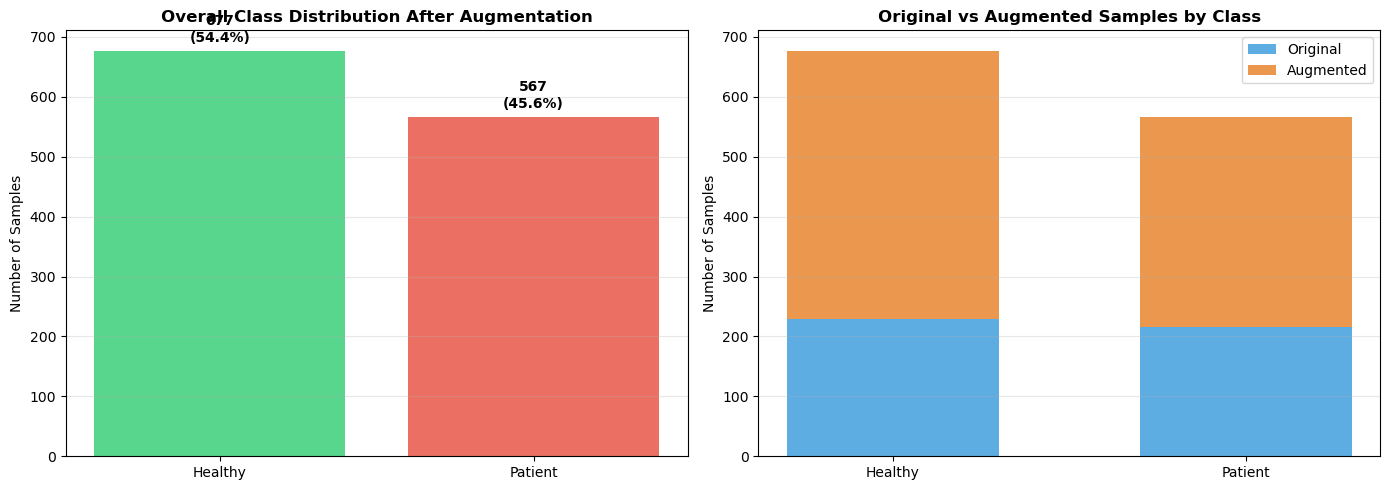

In [16]:
# =====================================
# CLASS BALANCE AFTER AUGMENTATION
# =====================================

print("\n--- Class Balance Analysis ---")

# Overall class distribution
class_dist = df_train['label'].value_counts()
print(f"\nOverall Class Distribution:")
print(f"  Healthy (0): {class_dist[0]} samples ({class_dist[0]/len(df_train)*100:.2f}%)")
print(f"  Patient (1): {class_dist[1]} samples ({class_dist[1]/len(df_train)*100:.2f}%)")

# Class distribution for original vs augmented
orig_class = df_train[df_train['augmented']==False]['label'].value_counts()
aug_class = df_train[df_train['augmented']==True]['label'].value_counts()

print(f"\nOriginal Samples:")
print(f"  Healthy: {orig_class[0]}, Patient: {orig_class[1]}")
print(f"\nAugmented Samples:")
print(f"  Healthy: {aug_class[0]}, Patient: {aug_class[1]}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall class balance
axes[0].bar(['Healthy', 'Patient'], class_dist.values, color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_title('Overall Class Distribution After Augmentation', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(class_dist.values):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df_train)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Stacked bar for original vs augmented by class
x = np.arange(2)
width = 0.6
axes[1].bar(x, orig_class.values, width, label='Original', color='#3498db', alpha=0.8)
axes[1].bar(x, aug_class.values, width, bottom=orig_class.values, 
           label='Augmented', color='#e67e22', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Healthy', 'Patient'])
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Original vs Augmented Samples by Class', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Feature Engineering

Extracting comprehensive features from sliding windows (1-second windows with 50% overlap) across 5 sensor channels:
- **Basic Statistics**: Mean, std, min, max, range, median
- **Derivatives**: Jerk (1st derivative) and snap (2nd derivative) mass features
- **FFT Features**: Dominant frequency, spectral entropy, energy distribution across frequency bands (low: 0.1-5Hz, mid: 5-20Hz, high: 20-50Hz)

These features capture signal amplitude, variability, motion dynamics, and frequency characteristics relevant to Parkinson's tremor and bradykinesia patterns.

### Feature Extraction Functions
- **Statistical Features**: compute_basic_stats() for 6 descriptive metrics per channel
- **Motion Features**: compute_derivatives() for jerk and snap, compute_mass() for motion intensity
- **Frequency Features**: compute_fft_features() for 7 spectral characteristics
- **Windowing**: extract_features_from_window() with 1000ms windows, 500ms overlap

### Feature Computation
- **Training Set**: Extract features from augmented training signals
- **Test Set**: Extract features from original test signals
- **Output**: 65 features × N_windows rows per dataset

### Feature Analysis
- **Feature Count**: Report total extracted features (65 per window)
- **Class Comparison**: Visualize mean features and jerk mass by channel
- **Discriminative Power**: Assess feature separability between classes

### Correlation Analysis
- **Heatmap**: Display correlation matrix for 15 key features
- **Redundancy Detection**: Identify highly correlated pairs (|r| > 0.8)
- **Multicollinearity**: Flag potential issues for model training

### Distribution Analysis
- **Histograms**: Compare feature distributions between healthy and patient groups
- **Overlap Assessment**: Evaluate classification task difficulty
- **Variance Analysis**: Quantify intra-class variability

### Window Statistics
- **Windows per File**: Distribution of extracted windows across files
- **Consistency Check**: Verify similar window counts in train/test sets
- **Temporal Coverage**: Confirm sufficient temporal context per file

This feature engineering transforms raw time-series into 65-dimensional feature vectors for machine learning.

In [17]:
# =====================================
# FEATURE ENGINEERING
# =====================================

def compute_basic_stats(signal):
    """Compute only basic statistics"""
    return {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "min": np.min(signal),
        "max": np.max(signal),
        "range": np.max(signal) - np.min(signal),
        "median": np.median(signal),
    }

def compute_derivatives(signal, order=1, sampling_rate=1000):
    """Compute derivatives up to snap (2nd derivative)"""
    dt = 1 / sampling_rate
    derivative = signal.copy()
    for _ in range(order):
        derivative = np.gradient(derivative, dt)
    return derivative

def compute_mass(signal):
    """Compute motion mass (sum of absolute values)"""
    return np.sum(np.abs(signal))

def compute_fft_features(signal, sampling_rate=1000):
    """Compute Fast Fourier Transform (FFT) based features"""
    N = len(signal)
    if N == 0:
        return {} # Return empty dict if signal is empty

    # Compute FFT and the corresponding frequencies
    yf = np.fft.fft(signal)
    xf = np.fft.fftfreq(N, 1 / sampling_rate)

    # Use only the positive half of the spectrum
    yf_mag = np.abs(yf[0:N//2])
    xf_pos = xf[0:N//2]
    
    if len(yf_mag) == 0:
        return {} # Return empty if magnitude is empty

    # Dominant frequency
    dominant_freq = xf_pos[np.argmax(yf_mag)] if len(xf_pos) > 0 else 0

    # Spectral entropy
    power_spectrum = yf_mag**2
    # Normalize to be a probability distribution
    norm_power = power_spectrum / np.sum(power_spectrum) if np.sum(power_spectrum) > 0 else power_spectrum
    spectral_entropy = entropy(norm_power)

    # Energy in frequency bands (example bands)
    energy_low = np.sum(power_spectrum[(xf_pos >= 0.1) & (xf_pos < 5)])
    energy_mid = np.sum(power_spectrum[(xf_pos >= 5) & (xf_pos < 20)])
    energy_high = np.sum(power_spectrum[(xf_pos >= 20) & (xf_pos < 50)])

    return {
        "fft_mean": np.mean(yf_mag),
        "fft_std": np.std(yf_mag),
        "fft_dominant_freq": dominant_freq,
        "fft_spectral_entropy": spectral_entropy,
        "fft_energy_low": energy_low,
        "fft_energy_mid": energy_mid,
        "fft_energy_high": energy_high,
    }

def extract_features_from_window(window_data, sampling_rate=1000):
    """Simplified feature extraction"""
    features = {}
    
    for i, channel in enumerate(channel_names):
        signal = window_data[:, i]
        stats = compute_basic_stats(signal)
        
        for stat_name, stat_val in stats.items():
            features[f"{channel}_{stat_name}"] = stat_val
        
        # First and second derivatives
        jerk = compute_derivatives(signal, order=1, sampling_rate=sampling_rate)
        snap = compute_derivatives(signal, order=2, sampling_rate=sampling_rate)
        
        # Only mass features
        features[f"{channel}_jerk_mass"] = compute_mass(jerk)
        features[f"{channel}_snap_mass"] = compute_mass(snap)
        
        fft_features = compute_fft_features(signal, sampling_rate=sampling_rate)
        for feat_name, feat_val in fft_features.items():
            features[f"{channel}_{feat_name}"] = feat_val
    
    return features

# Sliding window feature extraction
window_size = 1000  # 1 second
step_size = 500     # 50% overlap
sampling_rate = 1000

def extract_features_from_df(df):
    features = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        signal = row["signal"]
        label = row["label"]
        file_name = row["file_name"]
        
        # Get all metadata columns
        metadata = {k: v for k, v in row.items()
                   if k not in ['signal', 'label', 'file_name']}
        
        if signal.shape[0] < window_size:
            continue
        
        for start in range(0, signal.shape[0] - window_size + 1, step_size):
            end = start + window_size
            window_data = signal[start:end, :]
            
            window_features = extract_features_from_window(window_data, sampling_rate)
            window_features["label"] = label
            window_features["file_name"] = file_name
            window_features["start_index"] = start
            window_features["end_index"] = end
            
            # Add all metadata to the window features
            window_features.update(metadata)
            features.append(window_features)
    
    return pd.DataFrame(features)

# Extract features for each split
print("\nExtracting features for training set...")
df_features_train = extract_features_from_df(df_train)

print("Extracting features for test set...")
df_features_test = extract_features_from_df(df_test)

print("\nFeature extraction complete:")
print(f"Training set shape: {df_features_train.shape}")
print(f"Test set shape: {df_features_test.shape}")


Extracting features for training set...


100%|██████████| 1244/1244 [01:40<00:00, 12.41it/s]


Extracting features for test set...


100%|██████████| 80/80 [00:08<00:00,  9.80it/s]


Feature extraction complete:
Training set shape: (32637, 86)
Test set shape: (2577, 83)



--- Feature Engineering Summary ---
Total features extracted: 75
Training windows: 32637
Test windows: 2577


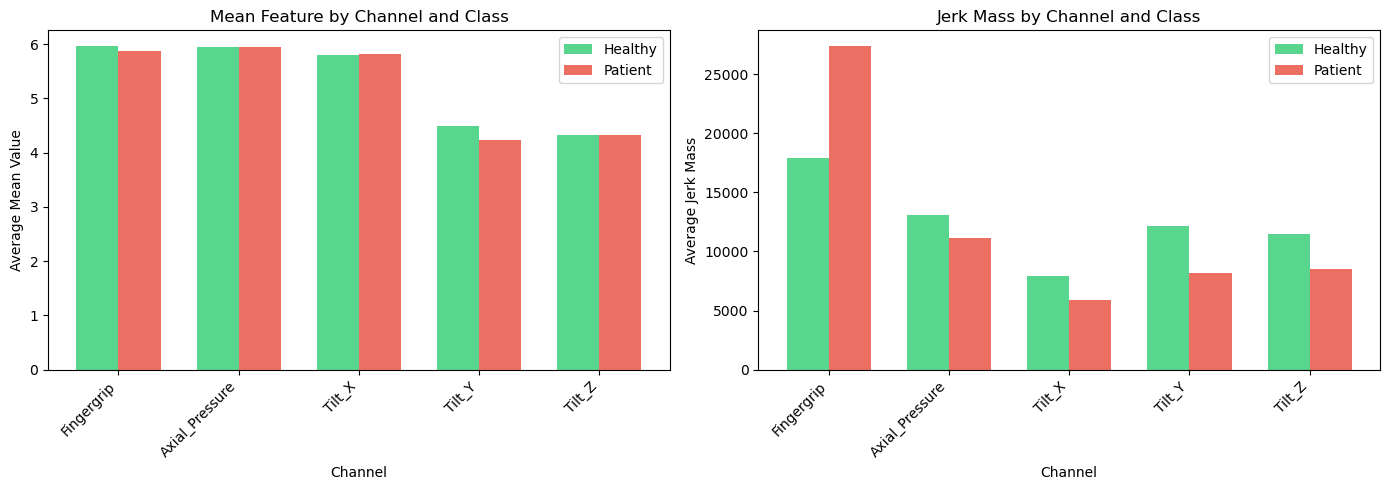

In [18]:
# =====================================
# FEATURE ENGINEERING VISUALIZATIONS
# =====================================

print("\n--- Feature Engineering Summary ---")

# Feature count
feature_cols = [col for col in df_features_train.columns 
                if col not in ['label', 'file_name', 'start_index', 'end_index', 
                               'Person_ID_Number', 'Age', 'Gender', 'Writing_Hand',
                               'augmented', 'original_duration', 'target_duration']]
print(f"Total features extracted: {len(feature_cols)}")
print(f"Training windows: {len(df_features_train)}")
print(f"Test windows: {len(df_features_test)}")

# Simple comparison of key features by class
x = np.arange(len(channel_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean features
mean_healthy = [df_features_train[df_features_train['label']==0][f"{ch}_mean"].mean() 
                for ch in channel_names]
mean_patient = [df_features_train[df_features_train['label']==1][f"{ch}_mean"].mean() 
                for ch in channel_names]

axes[0].bar(x - width/2, mean_healthy, width, label='Healthy', color='#2ecc71', alpha=0.8)
axes[0].bar(x + width/2, mean_patient, width, label='Patient', color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Average Mean Value')
axes[0].set_title('Mean Feature by Channel and Class')
axes[0].set_xticks(x)
axes[0].set_xticklabels(channel_names, rotation=45, ha='right')
axes[0].legend()

# Jerk Mass features
jerk_healthy = [df_features_train[df_features_train['label']==0][f"{ch}_jerk_mass"].mean() 
                for ch in channel_names]
jerk_patient = [df_features_train[df_features_train['label']==1][f"{ch}_jerk_mass"].mean() 
                for ch in channel_names]

axes[1].bar(x - width/2, jerk_healthy, width, label='Healthy', color='#2ecc71', alpha=0.8)
axes[1].bar(x + width/2, jerk_patient, width, label='Patient', color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Average Jerk Mass')
axes[1].set_title('Jerk Mass by Channel and Class')
axes[1].set_xticks(x)
axes[1].set_xticklabels(channel_names, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()


--- Feature Correlation Analysis ---


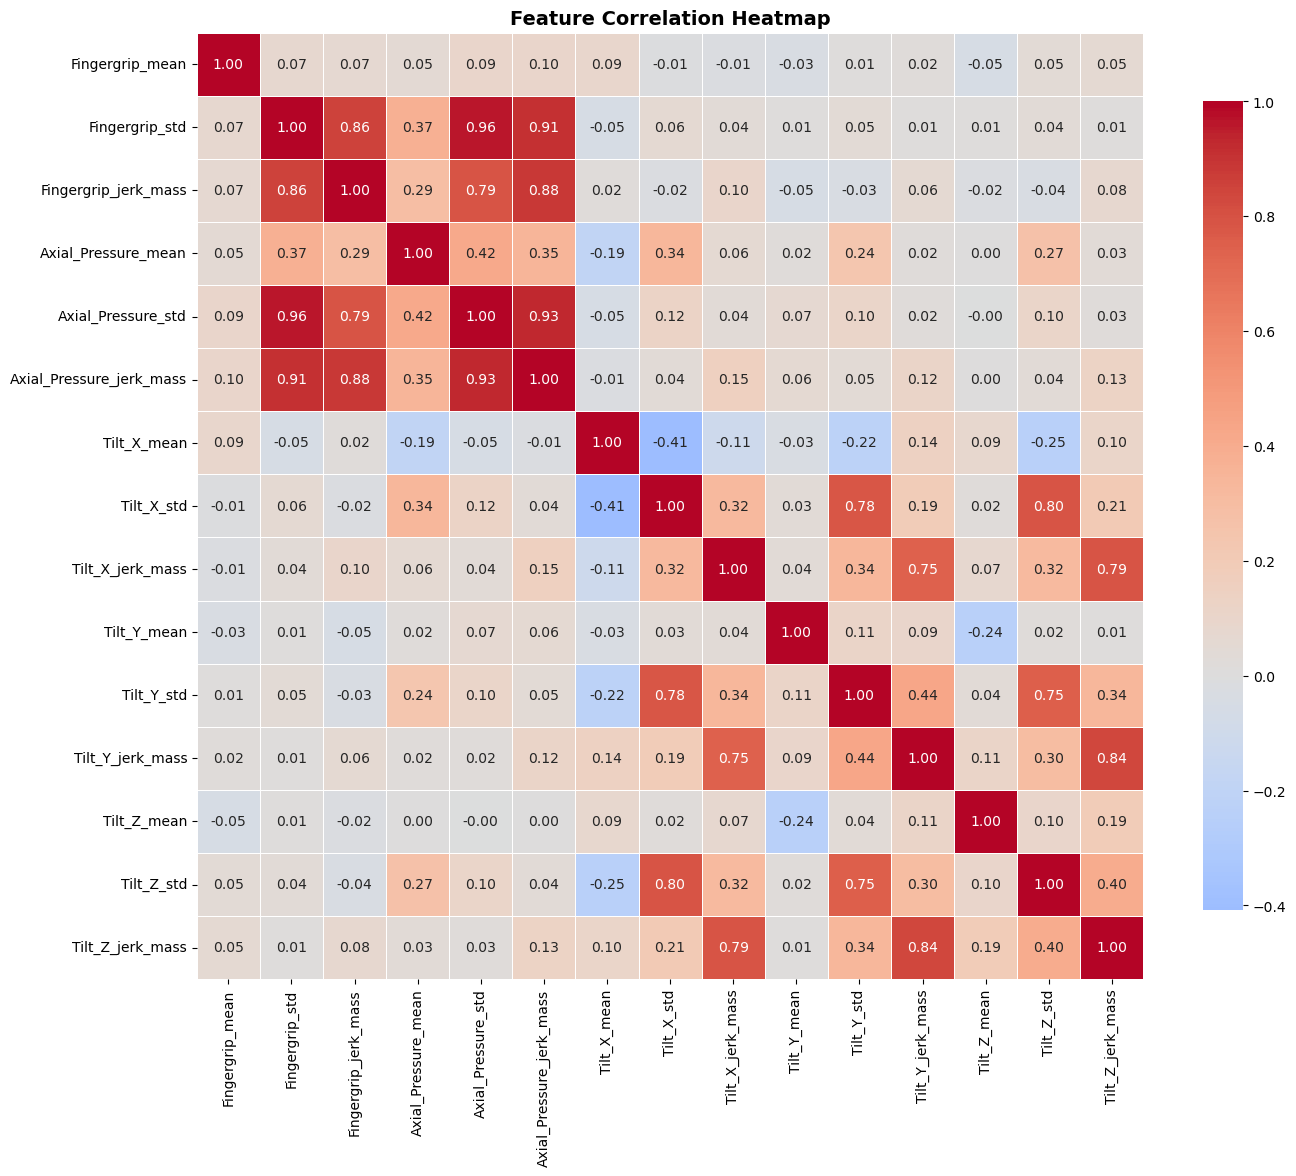


--- Highly Correlated Feature Pairs (|correlation| > 0.8) ---
           Feature 1                Feature 2  Correlation
      Fingergrip_std     Fingergrip_jerk_mass     0.855974
      Fingergrip_std       Axial_Pressure_std     0.960523
      Fingergrip_std Axial_Pressure_jerk_mass     0.910470
Fingergrip_jerk_mass Axial_Pressure_jerk_mass     0.878960
  Axial_Pressure_std Axial_Pressure_jerk_mass     0.930015
    Tilt_Y_jerk_mass         Tilt_Z_jerk_mass     0.836481


In [19]:
# =====================================
# FEATURE CORRELATION HEATMAP
# =====================================
import seaborn as sns

print("\n--- Feature Correlation Analysis ---")

# Select important features for correlation
important_features = []
for channel in channel_names:
    important_features.extend([
        f"{channel}_mean",
        f"{channel}_std",
        f"{channel}_jerk_mass"
    ])

# Filter to only include features that exist
important_features = [f for f in important_features if f in df_features_train.columns]

if important_features:
    # Calculate correlation matrix
    correlation_matrix = df_features_train[important_features].corr()
    
    # Plot heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Find highly correlated features
    print("\n--- Highly Correlated Feature Pairs (|correlation| > 0.8) ---")
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.8:
                high_corr_pairs.append({
                    'Feature 1': correlation_matrix.columns[i],
                    'Feature 2': correlation_matrix.columns[j],
                    'Correlation': correlation_matrix.iloc[i, j]
                })
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs)
        print(high_corr_df.to_string(index=False))
    else:
        print("No highly correlated pairs found.")


--- Feature Distribution by Class ---


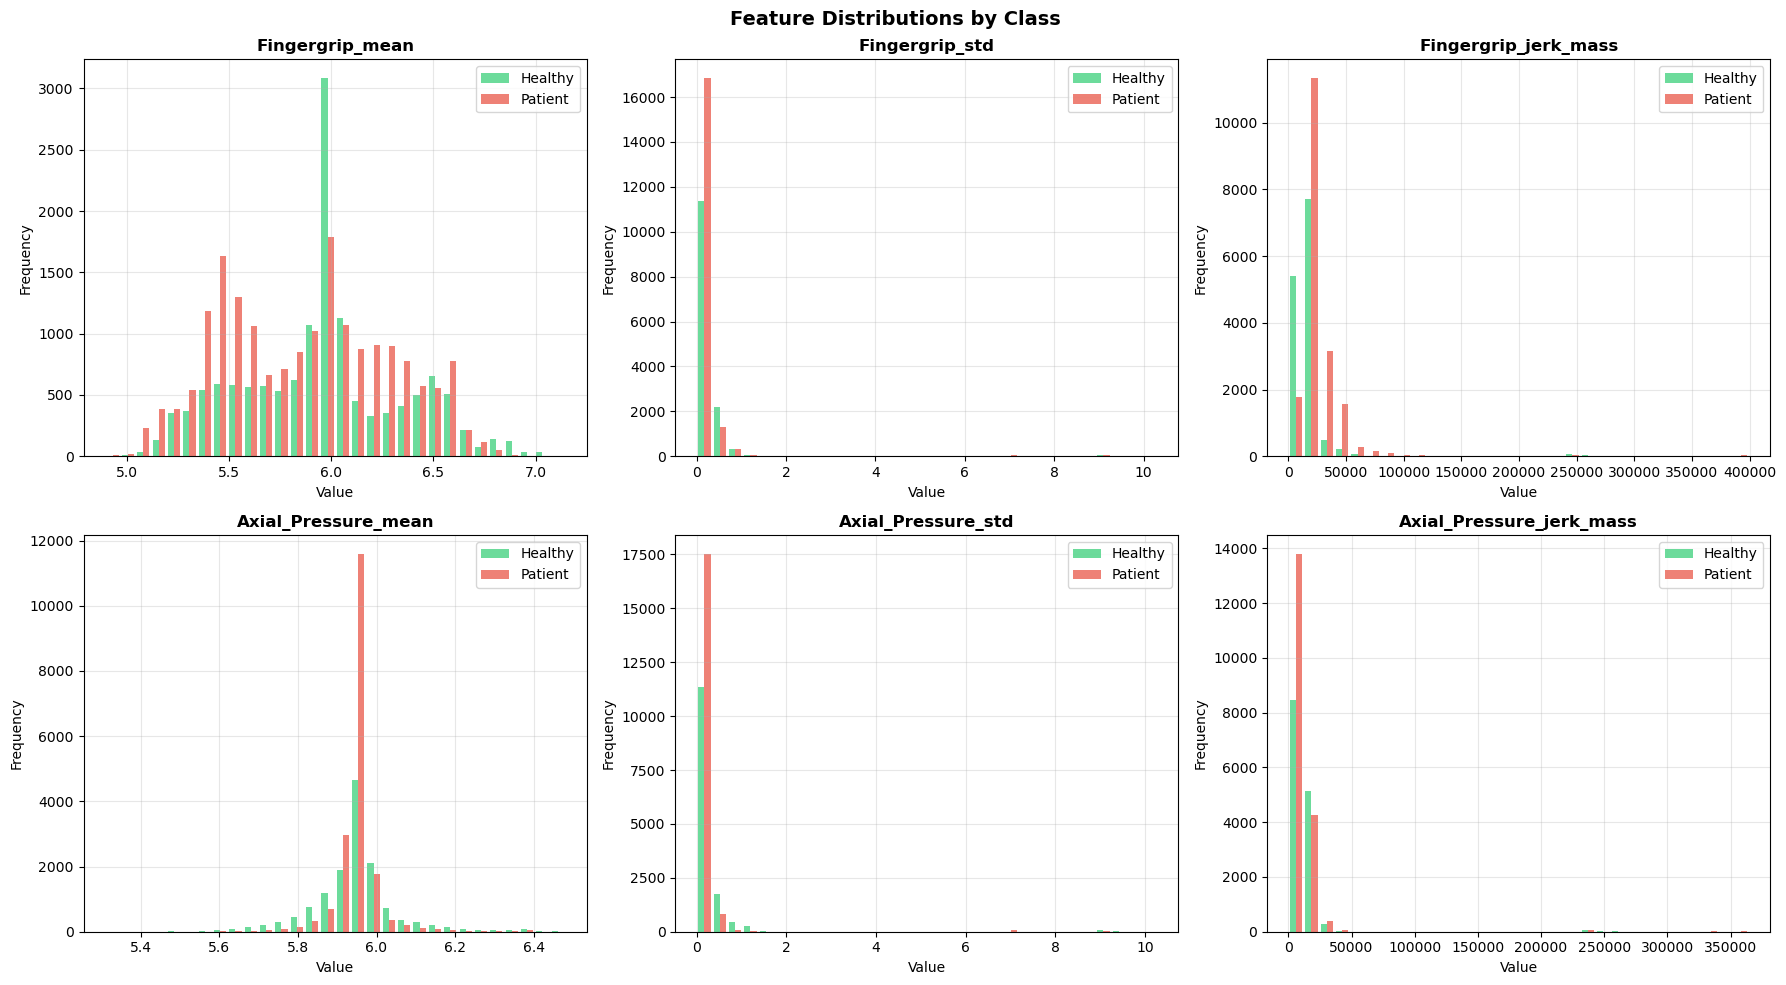

In [20]:
# =====================================
# FEATURE DISTRIBUTION BY CLASS
# =====================================

print("\n--- Feature Distribution by Class ---")

# Select sample features to visualize
sample_features = [
    'Fingergrip_mean', 'Fingergrip_std', 'Fingergrip_jerk_mass',
    'Axial_Pressure_mean', 'Axial_Pressure_std', 'Axial_Pressure_jerk_mass'
]

# Filter to only include features that exist
sample_features = [f for f in sample_features if f in df_features_train.columns]

if sample_features:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, feature in enumerate(sample_features):
        healthy_data = df_features_train[df_features_train['label']==0][feature]
        patient_data = df_features_train[df_features_train['label']==1][feature]
        
        axes[i].hist([healthy_data, patient_data], 
                     label=['Healthy', 'Patient'], 
                     bins=30, 
                     color=['#2ecc71', '#e74c3c'],
                     alpha=0.7)
        axes[i].set_title(f'{feature}', fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].legend()
        axes[i].grid(alpha=0.3)
    
    plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


--- Window Count per File Analysis ---
Training Set:
  Mean windows per file: 73.34
  Median windows per file: 67.00
  Min: 17, Max: 218

Test Set:
  Mean windows per file: 32.21
  Median windows per file: 25.00
  Min: 10, Max: 150


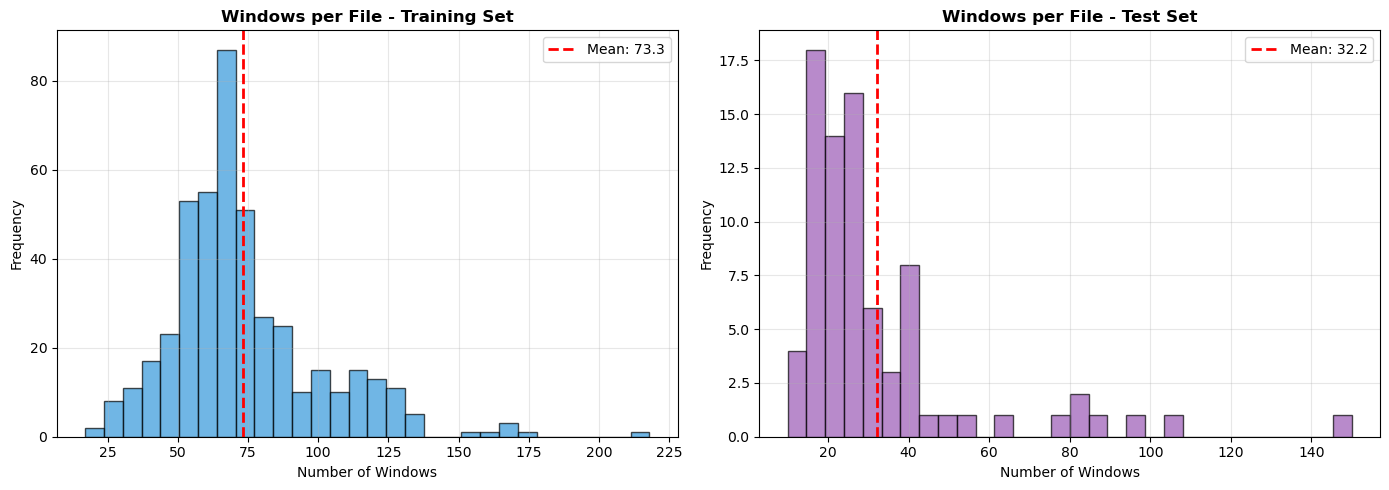

In [21]:
# =====================================
# WINDOW COUNT ANALYSIS
# =====================================

print("\n--- Window Count per File Analysis ---")

windows_per_file_train = df_features_train.groupby('file_name').size()
windows_per_file_test = df_features_test.groupby('file_name').size()

print(f"Training Set:")
print(f"  Mean windows per file: {windows_per_file_train.mean():.2f}")
print(f"  Median windows per file: {windows_per_file_train.median():.2f}")
print(f"  Min: {windows_per_file_train.min()}, Max: {windows_per_file_train.max()}")

print(f"\nTest Set:")
print(f"  Mean windows per file: {windows_per_file_test.mean():.2f}")
print(f"  Median windows per file: {windows_per_file_test.median():.2f}")
print(f"  Min: {windows_per_file_test.min()}, Max: {windows_per_file_test.max()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(windows_per_file_train, bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].axvline(windows_per_file_train.mean(), color='r', linestyle='--', 
                linewidth=2, label=f'Mean: {windows_per_file_train.mean():.1f}')
axes[0].set_title('Windows per File - Training Set', fontweight='bold')
axes[0].set_xlabel('Number of Windows')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(windows_per_file_test, bins=30, color='#9b59b6', alpha=0.7, edgecolor='black')
axes[1].axvline(windows_per_file_test.mean(), color='r', linestyle='--', 
                linewidth=2, label=f'Mean: {windows_per_file_test.mean():.1f}')
axes[1].set_title('Windows per File - Test Set', fontweight='bold')
axes[1].set_xlabel('Number of Windows')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Delta Features

Computing temporal changes between consecutive windows within each file:
- **Delta Features**: First-order differences of all extracted features (Δfeature = feature_t - feature_{t-1})
- **Purpose**: Capture temporal dynamics and rate of change in writing behavior
- **Implementation**: Group by file, sort by start_index, compute diff(), fill first window with 0

Delta features help the model detect progression patterns and temporal trends in motor symptoms.

### Delta Computation
- **Temporal Differences**: Calculate change in each feature between consecutive windows
- **File-Level Processing**: Group by file_name to preserve temporal continuity
- **Initialization**: Set first window deltas to 0 (no previous reference)

### Output
- **Feature Expansion**: Double feature count (65 original + 65 delta = 130 total)
- **Training Set**: df_delta_train with 130 features
- **Test Set**: df_delta_test with 130 features

This temporal feature engineering enables models to learn from both absolute values and rates of change.


In [22]:
# =====================================
# ADD DELTA FEATURES
# =====================================

def add_delta_features(df):
    delta_features = []
    grouped = df.groupby("file_name")
    
    # Define columns to keep
    base_non_feature_cols = [
        'label', 'file_name', 'start_index', 'end_index',
        'Person_ID_Number', 'Age', 'Gender', 'Writing_Hand',
        'augmented', 'original_duration', 'target_duration'
    ]
    
    # Identify metadata columns
    potential_metadata_cols = [
        col for col in df.columns
        if col not in base_non_feature_cols
        and col in ['Person_ID_Number', 'Age', 'Gender', 'Writing_Hand']
        and df.groupby('file_name')[col].nunique().max() == 1
    ]
    
    non_feature_cols = base_non_feature_cols + potential_metadata_cols
    
    for file_name, group in grouped:
        group = group.sort_values("start_index").reset_index(drop=True)
        group_delta = group.copy()
        
        # Identify feature columns
        feature_cols = [col for col in group.columns if col not in non_feature_cols]
        
        # Compute deltas only for feature columns
        for col in feature_cols:
            group_delta[f"delta_{col}"] = group[col].diff()
        
        # Fill first row deltas with 0
        delta_cols = [f"delta_{col}" for col in feature_cols]
        group_delta.loc[0, delta_cols] = 0
        
        delta_features.append(group_delta)
    
    return pd.concat(delta_features, ignore_index=True)

# Process each split
print("\nAdding delta features to training set...")
df_delta_train = add_delta_features(df_features_train)

print("Adding delta features to test set...")
df_delta_test = add_delta_features(df_features_test)

print("\nFinal shapes:")
print(f"Training set: {df_delta_train.shape}")
print(f"Test set: {df_delta_test.shape}")


Adding delta features to training set...
Adding delta features to test set...

Final shapes:
Training set: (32637, 161)
Test set: (2577, 158)


# Data Export

Saving processed datasets for model training:
- **Training Data**: df_delta_train saved to 'df_train.pkl'
- **Test Data**: df_delta_test saved to 'df_test.pkl'
- **Format**: Pickle serialization for fast loading and structure preservation

Final datasets ready for BiLSTM model training with 130 features per window.

In [23]:
# Save df_delta_train and df_delta_test
df_delta_train.to_pickle('df_train.pkl')
df_delta_test.to_pickle('df_test.pkl')

print("\ndf_delta_train and df_delta_test have been saved.")


df_delta_train and df_delta_test have been saved.
